<div class='titre_h'style='text-shadow:0 0 2px #000,0 0 30px #000,0px 0px 5px #000, 0 0 150px #000;color:#fff;font-weight:bold;background: #fff;/*border: solid #F6E5CB 1px;*/padding: 10px;border-radius:0 4px 4px 4px;-moz-border-radius: 0px 4px 4px 4px;-webkit-border-radius: 0px 4px 4px 4px;/*border: solid #F67F2B 15px;*/background-color:#fff;text-align:center;'>
  <h1>Implémentez un modèle de scoring</h1>
<br>
</div>
<p align="center" style='text-align:center;'><img src="https://bfsi.eletsonline.com/wp-content/uploads/2015/09/home-credit20120926124427_l.jpg" width="300" title="hover text"/>
</p>
<br>
<form>
  <fieldset>
    <legend class="alert alert-success" role="alert" style='margin:0 auto;'>
    <h4><b>Introduction :</b></h4>
    </legend>
    <br>
    <p class='tab2 active'><strong><span class="alert alert-info" role="alert">Contexte :</span></strong> </p>
    <br>
    <p>L’entreprise «HOME CREDIT» souhaite mettre en oeuvre un outil de «scoring crédit» pour calculer la probabilité qu’un client rembourse son crédit, puis classifie la demande en crédit accordé ou refusé. Elle souhaite donc développer un algorithme de classification en s’appuyant sur des sources de données variées (données comportementales, données provenant d'autres institutions financières, etc.).<br>
      Prêt à dépenser décide de développer un Dashboard interactif pour que les chargés de relation client puissent à la fois expliquer de façon la plus transparente possible les décisions d’octroi de crédit, mais également permettre à leurs clients de disposer de leurs informations personnelles et de les explorer facilement.</p>
    <br>
    <p class='tab2 active'><strong><span class="alert alert-info" role="alert">Mission :</span></strong></p>
    <br>
    <div class='description2'>
      <p align='left'><img src='https://www.icone-png.com/png/29/29379.png' width='20px' height='20px' align='top' /> Construire un modèle de scoring qui donnera une prédiction sur la probabilité de faillite d'un client de façon automatique.</p>
      <p align='left'><img src='https://www.icone-png.com/png/29/29379.png' width='20px' height='20px' align='top' /> Construire un Dashboard interactif à destination des gestionnaires de la relation client permettant d'interpréter les prédictions faites par le modèle, et d’améliorer la connaissance client des chargés de relation client.</p>
    </div>
  </fieldset>
</form>
</br>
<form>
  <fieldset>
    <legend class="alert alert-success" role="alert" style='margin:0 auto;'>
    <h4><b>Découverte des données:</b></h4>
    </legend>
    <br>
    <table width='100%' class='product-attribute-specs-table' id='product-attribute-specs-table'>
      <tr class='first odd'>
        <th class='label' style='background-color:#ECEBEB; text-align:left;font-weight:bold' width='30%'>application_train.csv</th>
        <td class='data last' width='50%'>Les principales données de formation avec des informations sur chaque demande de prêt chez Prêt à dépenser.</td>
      </tr>
      <tr class='even'>
        <th width='30%' class='label' style='background-color:#ECEBEB; text-align:left'>bureau.csv</th>
        <td width='30%' class='data last'>Données concernant les crédits antérieurs du client auprès d'autres institutions financières.</td>
      </tr>
      <tr class='last odd'>
        <th width='30%' class='label' style='background-color:#ECEBEB; text-align:left'>bureau_balance.csv</th>
        <td width='30%' class='data last'>Données mensuelles détaillées sur les crédits précédents dans le fichier bureau.csv</td>
      </tr>
      <tr class='last odd'>
        <th class='label' style='background-color:#ECEBEB; text-align:left'>credit_card_balance.csv</th>
        <td class='data last'>Données mensuelles sur les cartes de crédit précédentes que les clients ont eues avec Prêt à dépenser.</td>
      </tr>
      <tr class='last odd'>
        <th class='label' style='background-color:#ECEBEB; text-align:left'>installments_payments.csv</th>
        <td class='data last'>Historique de paiement pour les prêts précédents chez Prêt à dépenser.</td>
      </tr>
      <tr class='last odd'>
        <th width='30%' class='label' style='background-color:#ECEBEB; text-align:left'>previous_application.csv</th>
        <td width='30%' class='data last'>Demandes précédentes de prêts chez Prêt à dépenser des clients qui ont des prêts dans le fichier application_train.csv</td>
      </tr>
      <tr class='last odd'>
        <th width='30%' class='label' style='background-color:#ECEBEB; text-align:left'>POS_CASH_balance.csv</th>
        <td width='30%' class='data last'>Données mensuelles sur les clients précédents.</td>
      </tr>
    </table>
  </fieldset>
</form>


 # **<font color='blue'/>Importation des packages et chargement des données**

---



In [1]:
pip install shap

In [24]:
pip install imbalanced-learn

In [3]:
pip install shapely

In [4]:
pip install lightgbm

In [5]:
pip install pyarrow

In [6]:
# pip install pivottablejs

In [7]:
# pip install ipypivot

Importation des packages

In [8]:
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

from sklearn.feature_extraction.text import TfidfVectorizer

from scipy.stats import uniform as sp_uniform, randint as sp_randint

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, LabelEncoder, LabelBinarizer
from sklearn import metrics
from sklearn.metrics import adjusted_rand_score, classification_report, ConfusionMatrixDisplay, recall_score, precision_score

from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

import lightgbm as lgbm
from lightgbm import LGBMClassifier
from lightgbm import plot_importance

from sklearn.decomposition import PCA

from sklearn.impute import KNNImputer

from sklearn.model_selection import train_test_split, cross_val_score, validation_curve, GridSearchCV, RandomizedSearchCV, StratifiedKFold, KFold

from sklearn.feature_selection import RFECV

from sklearn import metrics
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, LabelBinarizer

from sklearn import linear_model
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

from sklearn.pipeline import make_pipeline, Pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline



from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer, make_column_selector,ColumnTransformer

from xgboost import XGBRegressor, XGBClassifier
from xgboost import plot_importance

import shap

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator
import matplotlib as mpl

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from scipy.stats import kde

from sklearn.metrics import roc_curve
from matplotlib import pyplot
from numpy import sqrt
from numpy import argmax
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from numpy import arange

import os,shutil
import cv2
from urllib import request
import glob
import pickle as pk
import re

import zipfile as zf
import tarfile

from PIL import Image

chargement des données

In [9]:
url="https://s3-eu-west-1.amazonaws.com/static.oc-static.com/prod/courses/files/Parcours_data_scientist/Projet+-+Impl%C3%A9menter+un+mod%C3%A8le+de+scoring/Projet+Mise+en+prod+-+home-credit-default-risk.zip"
request.urlretrieve (url, "Projet+Mise+en+prod+-+home-credit-default-risk.zip")

('Projet+Mise+en+prod+-+home-credit-default-risk.zip',
 <http.client.HTTPMessage at 0x78ecea6e81a0>)

Dézipper le fichier zip contenant les données dans le dossier :

In [10]:
with zf.ZipFile('Projet+Mise+en+prod+-+home-credit-default-risk.zip', 'r') as f:
  f.extractall('Data')

Lire les fichiers csv importés, et les affecter à des DataFrames :

In [11]:
df_app_train             = pd.read_csv("Data/application_train.csv")
# df_app_test              = pd.read_csv("Data/application_test.csv")
df_bureau                = pd.read_csv("Data/bureau.csv")
df_bureau_balance        = pd.read_csv("Data/bureau_balance.csv")
df_credit_card_balance   = pd.read_csv("Data/credit_card_balance.csv")
df_installments_payments = pd.read_csv("Data/installments_payments.csv")
df_previous_application  = pd.read_csv("Data/previous_application.csv")
df_POS_CASH_balance      = pd.read_csv("Data/POS_CASH_balance.csv")
df_sample_submission     = pd.read_csv("Data/sample_submission.csv")

# **<font color='blue'/>Nettoyage des données**

---

## Exploration Data

In [12]:
df_app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Les colonnes de chaque DataFrame

In [13]:
print("application_train -  rows:",df_app_train.shape[0]," columns:", df_app_train.shape[1])
# print("application_test -  rows:",df_app_test.shape[0]," columns:", df_app_test.shape[1])
print("bureau -  rows:",df_bureau.shape[0]," columns:", df_bureau.shape[1])
print("bureau_balance -  rows:",df_bureau_balance.shape[0]," columns:", df_bureau_balance.shape[1])
print("credit_card_balance -  rows:",df_credit_card_balance.shape[0]," columns:", df_credit_card_balance.shape[1])
print("installments_payments -  rows:",df_installments_payments.shape[0]," columns:", df_installments_payments.shape[1])
print("previous_application -  rows:",df_previous_application.shape[0]," columns:", df_previous_application.shape[1])
print("POS_CASH_balance -  rows:",df_POS_CASH_balance.shape[0]," columns:", df_POS_CASH_balance.shape[1])
print("sample_submission -  rows:",df_sample_submission.shape[0]," columns:", df_sample_submission.shape[1])

application_train -  rows: 307511  columns: 122
bureau -  rows: 1716428  columns: 17
bureau_balance -  rows: 27299925  columns: 3
credit_card_balance -  rows: 3840312  columns: 23
installments_payments -  rows: 13605401  columns: 8
previous_application -  rows: 1670214  columns: 37
POS_CASH_balance -  rows: 10001358  columns: 8
sample_submission -  rows: 48744  columns: 2


## Bureau et Bureau Balance

**FUNCTIONS**

There are some useful functions in this section. They will help to understand the problem, exploratory data analysis, pre-processing and so on.

- Reduce Memory Usage
- One-Hot Encoder
- Finding column names and types
- An analyzer for Categorical Variables
- Plotting numerical variables
- Plotting correlations
- Finding high correlations
- Missing Value
- Quantile functions for aggregations
- Rare Encoder

In [14]:
# Reduce Memory Usage
def reduce_mem_usage(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df


# One-hot encoding for categorical columns with get_dummies
def one_hot_encoder(df, nan_as_category=True):
    original_columns = list(df.columns)
    categorical_columns = df.select_dtypes(["category", "object"]).columns.tolist()
    # categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns=categorical_columns, dummy_na=nan_as_category)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

# Grab Column Names
def grab_col_names(dataframe, cat_th=10, car_th=20, show_date=False):
    date_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "datetime64[ns]"]

    #cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    cat_cols = dataframe.select_dtypes(["object", "category"]).columns.tolist()



    num_but_cat = [col for col in dataframe.select_dtypes(["float", "integer"]).columns if dataframe[col].nunique() < cat_th]

    cat_but_car = [col for col in dataframe.select_dtypes(["object", "category"]).columns if dataframe[col].nunique() > car_th]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = dataframe.select_dtypes(["float", "integer"]).columns
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'date_cols: {len(date_cols)}')
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    # cat_cols + num_cols + cat_but_car = değişken sayısı.
    # num_but_cat cat_cols'un içerisinde zaten.
    # dolayısıyla tüm şu 3 liste ile tüm değişkenler seçilmiş olacaktır: cat_cols + num_cols + cat_but_car
    # num_but_cat sadece raporlama için verilmiştir.

    if show_date == True:
        return date_cols, cat_cols, cat_but_car, num_cols, num_but_cat
    else:
        return cat_cols, cat_but_car, num_cols, num_but_cat

# Categorical Variables & Target
def cat_analyzer(dataframe, variable, target = None):
    print(variable)
    if target == None:
        print(pd.DataFrame({
            "COUNT": dataframe[variable].value_counts(),
            "RATIO": dataframe[variable].value_counts() / len(dataframe)}), end="\n\n\n")
    else:
        temp = dataframe[dataframe[target].isnull() == False]
        print(pd.DataFrame({
            "COUNT":dataframe[variable].value_counts(),
            "RATIO":dataframe[variable].value_counts() / len(dataframe),
            "TARGET_COUNT":dataframe.groupby(variable)[target].count(),
            "TARGET_MEAN":temp.groupby(variable)[target].mean(),
            "TARGET_MEDIAN":temp.groupby(variable)[target].median(),
            "TARGET_STD":temp.groupby(variable)[target].std()}), end="\n\n\n")

# Numerical Variables
def corr_plot(data, remove=["Id"], corr_coef = "pearson", figsize=(20, 20)):
    if len(remove) > 0:
        num_cols2 = [x for x in data.columns if (x not in remove)]

    sns.set(font_scale=1.1)
    c = data[num_cols2].corr(method = corr_coef)
    mask = np.triu(c.corr(method = corr_coef))
    plt.figure(figsize=figsize)
    sns.heatmap(c,
                annot=True,
                fmt='.1f',
                cmap='coolwarm',
                square=True,
                mask=mask,
                linewidths=1,
                cbar=False)
    plt.show()

# Plot numerical variables
def num_plot(data, num_cols, remove=["Id"], hist_bins=10, figsize=(20, 4)):

    if len(remove) > 0:
        num_cols2 = [x for x in num_cols if (x not in remove)]

    for i in num_cols2:
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        data.hist(str(i), bins=hist_bins, ax=axes[0])
        data.boxplot(str(i), ax=axes[1], vert=False);
        try:
            sns.kdeplot(np.array(data[str(i)]))
        except:
            ValueError

        axes[1].set_yticklabels([])
        axes[1].set_yticks([])
        axes[0].set_title(i + " | Histogram")
        axes[1].set_title(i + " | Boxplot")
        axes[2].set_title(i + " | Density")
        plt.show()

# Get high correlated variables
def high_correlation(data, remove=['SK_ID_CURR', 'SK_ID_BUREAU'], corr_coef="pearson", corr_value = 0.7):
    if len(remove) > 0:
        cols = [x for x in data.columns if (x not in remove)]
        c = data[cols].corr(method=corr_coef)
    else:
        c = data.corr(method=corr_coef)

    for i in c.columns:
        cr = c.loc[i].loc[(c.loc[i] >= corr_value) | (c.loc[i] <= -corr_value)].drop(i)
        if len(cr) > 0:
            print(i)
            print("-------------------------------")
            print(cr.sort_values(ascending=False))
            print("\n")

# Missing Value
def missing_values(data, plot=False):
    mst = pd.DataFrame(
        {"Num_Missing": data.isnull().sum(), "Missing_Ratio": data.isnull().sum() / data.shape[0]}).sort_values(
        "Num_Missing", ascending=False)
    mst["DataTypes"] = data[mst.index].dtypes.values
    mst = mst[mst.Num_Missing > 0].reset_index().rename({"index": "Feature"}, axis=1)

    print("Number of Variables include Missing Values:", mst.shape[0], "\n")

    if mst[mst.Missing_Ratio >= 0.3].shape[0] > 0:
        print("Full Missing Variables:", mst[mst.Missing_Ratio >= 1.0].Feature.tolist())
        data.drop(mst[mst.Missing_Ratio >= 1.0].Feature.tolist(), axis=1, inplace=True)

        print("Full missing variables are deleted!", "\n")

    if plot:
        plt.figure(figsize=(25, 8))
        p = sns.barplot(mst.Feature, mst.Missing_Ratio)
        for rotate in p.get_xticklabels():
            rotate.set_rotation(90)
        plt.show()

    print(mst, "\n")


# Quantile functions for aggregations
def quantile_funcs(percentiles = [0.75, 0.9, 0.99]):
    return [(p, lambda x: x.quantile(p)) for p in percentiles]

# Rare Encoder
def rare_encoder(data, col, rare_perc):
    temp = data[col].value_counts() / len(data) < rare_perc
    data[col] = np.where(~data[col].isin(temp[temp < rare_perc].index), "Rare", data[col])



# Plot of multiple features, with TARGET = 1/0 on the same graph
def plot_stats(feature,label_rotation=False,horizontal_layout=True):
    temp = df_app_train[feature].value_counts()
    df1 = pd.DataFrame({feature: temp.index,'Number of contracts': temp.values})

    # Calculate the percentage of target=1 per category value
    cat_perc = df_app_train[[feature, 'TARGET']].groupby([feature],as_index=False).mean()
    #cat_perc.sort_values(by='TARGET', ascending=False, inplace=True)

    if(horizontal_layout):
        fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))
    else:
        fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12,14))
    sns.set_color_codes("pastel")
    s = sns.barplot(ax=ax1, x = feature, y="Number of contracts",data=df1)
    if(label_rotation):
        s.set_xticklabels(s.get_xticklabels(),rotation=90)

    s = sns.barplot(ax=ax2, x = feature, y='TARGET', order=cat_perc[feature], data=cat_perc)
    if(label_rotation):
        s.set_xticklabels(s.get_xticklabels(),rotation=90)
    plt.ylabel('Percent of target with value 1 [%]', fontsize=10)
    plt.tick_params(axis='both', which='major', labelsize=10)

#     # Ajouter les annotations sur les barres
#     for p in s.patches:
#         width, height = p.get_width(), p.get_height()
#         x, y = p.get_xy()
#         plt.annotate("%.2f" % p.get_height() + '%',
#                     (p.get_x()+p.get_width()/2, p.get_height()),
#                     ha='center',
#                     va='center',
#                     xytext=(0, 8),
#                     textcoords='offset points',
#                     fontsize = 10,
#                     )

    plt.show()

# Plot distribution of multiple features, with TARGET = 1/0 on the same graph
def plot_distribution_comp(var,nrow=2):

    colors = ['red', 'green']
    i = 0
    t1 = df_train.loc[df_train['TARGET'] != 0]
    t0 = df_train.loc[df_train['TARGET'] == 0]

    sns.set_style('whitegrid')
    plt.figure()
    fig, ax = plt.subplots(nrow,2,figsize=(12,6*nrow))

    for feature in var:
        i += 1
        plt.subplot(nrow,2,i)
        sns.kdeplot(t0[feature], bw_adjust=0.5,label="TARGET = 0")
        sns.kdeplot(t1[feature], bw_adjust=0.5,label="TARGET = 1")
        plt.ylabel('Density plot', fontsize=12)
        plt.xlabel(feature, fontsize=12)
        locs, labels = plt.xticks()
        plt.tick_params(axis='both', which='major', labelsize=12)
#         client = df_train[feature][df_train['SK_ID_CURR'] == 100020].values[0]
#         plt.axvline(client, c='red')
        plt.legend()
    plt.show()

In [15]:
df_bureau.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY'],
      dtype='object')

In [16]:
df_bureau[df_bureau['SK_ID_CURR'].duplicated()].sort_values(by='SK_ID_CURR', ascending=True)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
248490,100001,5896636,Active,currency 1,-320,0,411.0,NaN,NaN,0,168345.0,110281.50,NaN,0.0,Consumer credit,-10,9364.5
248487,100001,5896633,Closed,currency 1,-1572,0,-1329.0,-1328.0,NaN,0,85500.0,0.00,0.0,0.0,Consumer credit,-155,0.0
248486,100001,5896632,Closed,currency 1,-879,0,-514.0,-544.0,NaN,0,91620.0,0.00,0.0,0.0,Consumer credit,-155,0.0
248485,100001,5896631,Closed,currency 1,-909,0,-179.0,-877.0,NaN,0,279720.0,0.00,0.0,0.0,Consumer credit,-155,0.0
248489,100001,5896635,Active,currency 1,-49,0,1778.0,NaN,NaN,0,378000.0,373239.00,0.0,0.0,Consumer credit,-16,10822.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010006,456255,5126330,Closed,currency 1,-1021,0,-959.0,-959.0,NaN,0,22995.0,0.00,NaN,0.0,Consumer credit,-953,3244.5
1010008,456255,5126332,Active,currency 1,-378,0,27320.0,NaN,NaN,0,90000.0,61060.50,NaN,0.0,Credit card,-11,NaN
1010009,456255,5126333,Active,currency 1,-363,0,1463.0,NaN,0.000,0,436032.0,363573.54,0.0,0.0,Consumer credit,-25,0.0
1010010,456255,5126334,Active,currency 1,-451,0,279.0,NaN,15439.905,0,450000.0,191005.47,0.0,0.0,Consumer credit,-55,3244.5


In [17]:
print(df_app_train.shape)
print(df_bureau.shape)

(307511, 122)
(1716428, 17)


In [18]:
# print("The resulting dataframe `application_bureau_train` has ",application_bureau_train.shape[0]," rows and ",
#       application_bureau_train.shape[1]," columns.")

Nettoyage de df_bureau_balance

In [19]:
# One-Hot Encoder
bb, bb_cat = one_hot_encoder(df_bureau_balance, nan_as_category=False)

# Bureau balance: Perform aggregations and merge with bureau.csv
bb_aggregations = {'MONTHS_BALANCE': ['min', 'max', 'size']}

for col in bb_cat:
    bb_aggregations[col] = ['mean']

bb_agg = bb.groupby('SK_ID_BUREAU').agg(bb_aggregations)
bb_agg.columns = pd.Index([e[0] + "_" + e[1].upper() for e in bb_agg.columns.tolist()])

# Status Sum
bb_agg["STATUS_C0_MEAN_SUM"] = bb_agg[["STATUS_C_MEAN", "STATUS_0_MEAN"]].sum(axis = 1)
bb_agg["STATUS_12_MEAN_SUM"] = bb_agg[["STATUS_1_MEAN", "STATUS_2_MEAN"]].sum(axis = 1)
bb_agg["STATUS_345_MEAN_SUM"] = bb_agg[["STATUS_3_MEAN", "STATUS_4_MEAN", "STATUS_5_MEAN"]].sum(axis = 1)
bb_agg["STATUS_12345_MEAN_SUM"] = bb_agg[["STATUS_1_MEAN", "STATUS_2_MEAN", "STATUS_3_MEAN",
                                          "STATUS_4_MEAN", "STATUS_5_MEAN"]].sum(axis = 1)

# Find the first month when the credit is closed!
closed = df_bureau_balance[df_bureau_balance.STATUS == "C"]
closed = closed.groupby("SK_ID_BUREAU").MONTHS_BALANCE.min().reset_index().rename({"MONTHS_BALANCE":"MONTHS_BALANCE_FIRST_C"}, axis = 1)
closed["MONTHS_BALANCE_FIRST_C"] = np.abs(closed["MONTHS_BALANCE_FIRST_C"])
bb_agg = pd.merge(bb_agg, closed, how = "left", on = "SK_ID_BUREAU")
bb_agg["MONTHS_BALANCE_CLOSED_DIF"] = np.abs(bb_agg.MONTHS_BALANCE_MIN) - bb_agg.MONTHS_BALANCE_FIRST_C

del closed, bb_aggregations, df_bureau_balance, bb_cat

In [20]:
print("BURAU BALANCE SHAPE:", bb_agg.shape, "\n")

bb_agg.head()

BURAU BALANCE SHAPE: (817395, 18) 



,SK_ID_BUREAU,MONTHS_BALANCE_MIN,MONTHS_BALANCE_MAX,MONTHS_BALANCE_SIZE,STATUS_0_MEAN,STATUS_1_MEAN,STATUS_2_MEAN,STATUS_3_MEAN,STATUS_4_MEAN,STATUS_5_MEAN,STATUS_C_MEAN,STATUS_X_MEAN,STATUS_C0_MEAN_SUM,STATUS_12_MEAN_SUM,STATUS_345_MEAN_SUM,STATUS_12345_MEAN_SUM,MONTHS_BALANCE_FIRST_C,MONTHS_BALANCE_CLOSED_DIF
0,5001709,-96,0,97,0.000000,0.0,0.0,0.0,0.0,0.0,0.886598,0.113402,0.886598,0.0,0.0,0.0,85.0,11.0
1,5001710,-82,0,83,0.060241,0.0,0.0,0.0,0.0,0.0,0.578313,0.361446,0.638554,0.0,0.0,0.0,47.0,35.0
2,5001711,-3,0,4,0.750000,0.0,0.0,0.0,0.0,0.0,0.000000,0.250000,0.750000,0.0,0.0,0.0,NaN,NaN
3,5001712,-18,0,19,0.526316,0.0,0.0,0.0,0.0,0.0,0.473684,0.000000,1.000000,0.0,0.0,0.0,8.0,10.0
4,5001713,-21,0,22,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,0.0,0.0,0.0,NaN,NaN


In [21]:
pd.set_option('display.max_columns', 500)

Merge Bureau Balance and Bureau

In [22]:
# LEFT JOIN WITH BUREAU
bureau = pd.merge(df_bureau, bb_agg, how='left', on='SK_ID_BUREAU')
# del bb_agg

print(bureau.shape, "\n")

bureau.head()

(1716428, 34) 



,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,MONTHS_BALANCE_MIN,MONTHS_BALANCE_MAX,MONTHS_BALANCE_SIZE,STATUS_0_MEAN,STATUS_1_MEAN,STATUS_2_MEAN,STATUS_3_MEAN,STATUS_4_MEAN,STATUS_5_MEAN,STATUS_C_MEAN,STATUS_X_MEAN,STATUS_C0_MEAN_SUM,STATUS_12_MEAN_SUM,STATUS_345_MEAN_SUM,STATUS_12345_MEAN_SUM,MONTHS_BALANCE_FIRST_C,MONTHS_BALANCE_CLOSED_DIF
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Le taux de valeurs manquantes en % de bureau

ValueError: rotation must be 'vertical', 'horizontal' or a number, not 90

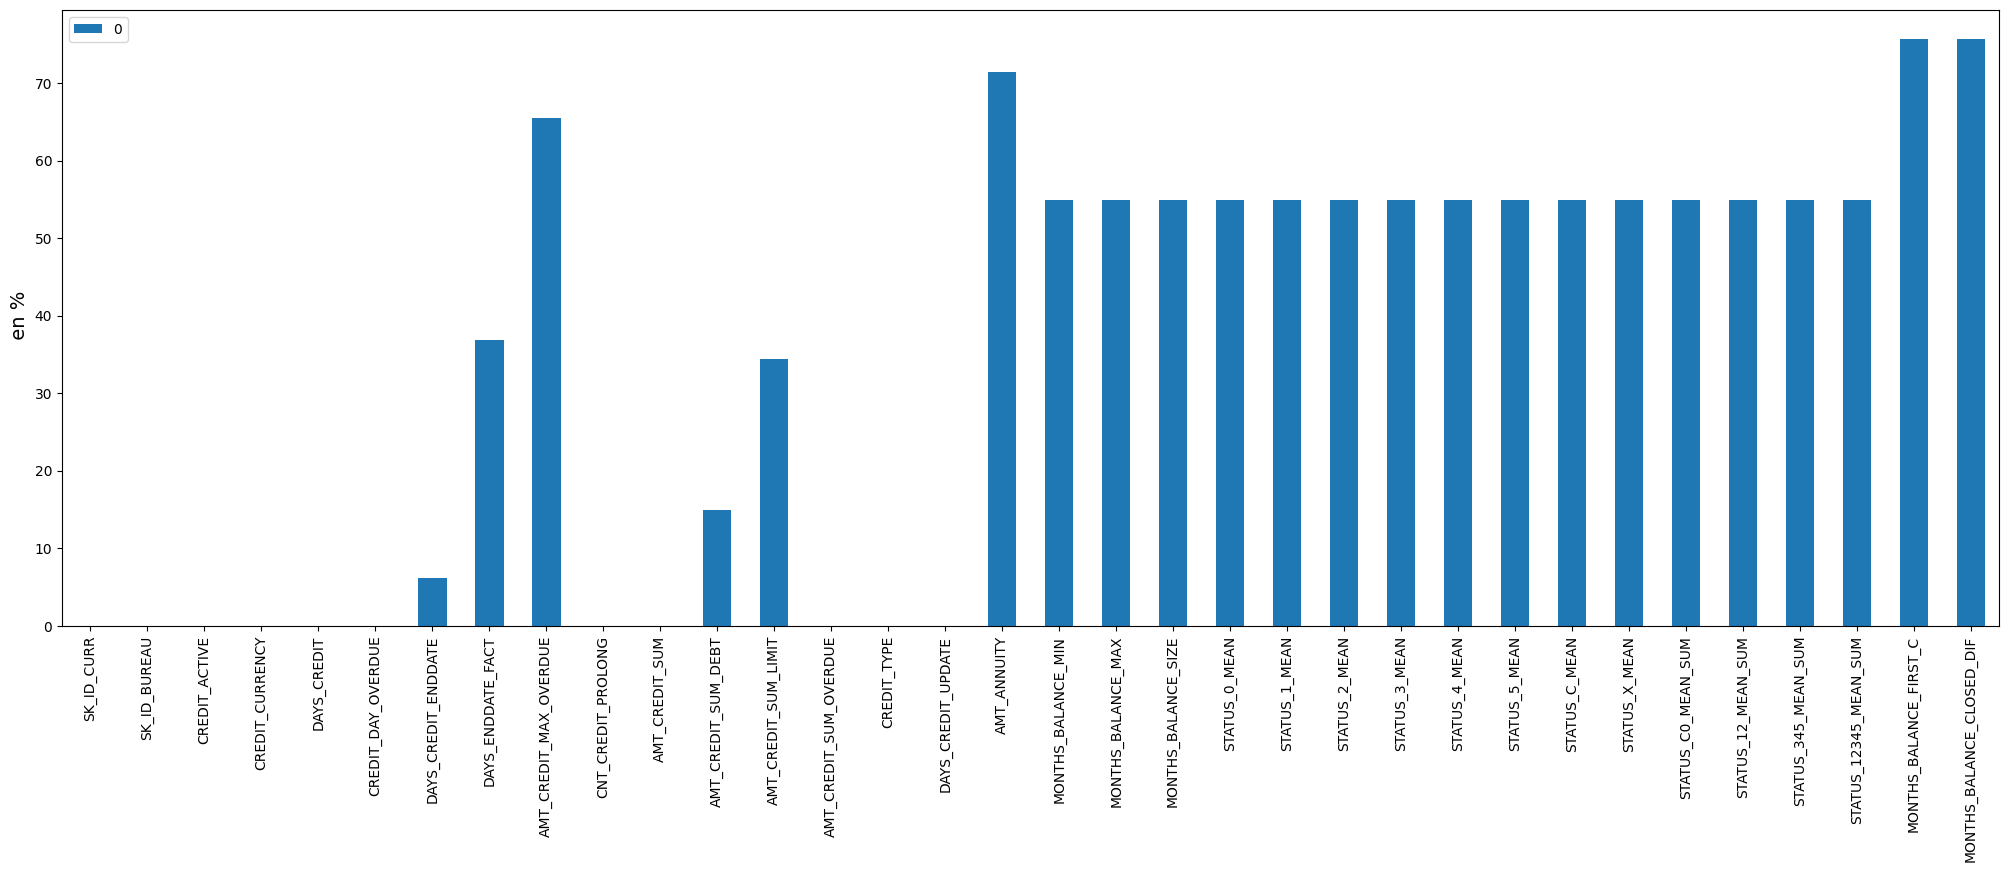

In [23]:
missing_rate = (bureau.isna().sum()/bureau.shape[0])*100
missing_rate

missing_rate = pd.DataFrame(missing_rate)
ax = missing_rate.plot.bar(figsize=(25,8))

ax.set_ylabel(" en %", fontsize=14)
plt.xticks(rotation='90', fontsize=14)
plt.title("Le taux de valeurs manquantes en % de bureau",fontsize=18)
# Ajouter les annotations sur les barres
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    plt.annotate(np.round(p.get_height(),decimals=2),
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize = 10,
                )

In [ ]:
# How many loans of each customer are there to from Credit Bureau?
bureau.groupby("SK_ID_CURR").SK_ID_BUREAU.count().hist(bins=50), plt.show()
bureau.groupby("SK_ID_CURR").SK_ID_BUREAU.count().agg({"min", "max", "mean", "median", "std"})

Manipulation de données de bureau

In [ ]:
# FEATURE ENGINEERING FOR BUREAU

# Categorical Variables
# -----------------------------------------------------------
# Useless
# bureau.drop("CREDIT_CURRENCY", axis = 1, inplace = True)

# Rare Categories
bureau["CREDIT_ACTIVE"] = np.where(bureau.CREDIT_ACTIVE.isin(["Sold", "Bad debt"]), "Sold_BadDebt", bureau.CREDIT_ACTIVE)

bureau["CREDIT_TYPE"] = np.where(
    ~bureau.CREDIT_TYPE.isin(
        ["Consumer credit", "Credit card", "Car loan", "Mortgage", "Microloan"]
    ), "Other", bureau["CREDIT_TYPE"])

# One-Hot Encoder
bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category=False)


# Numerical Variables
# -----------------------------------------------------------

# Bureau and bureau_balance numeric features
# cal = ['min', 'max', 'mean', 'sum', 'median','std']
cal = ['mean']
cols1 = [
    'DAYS_CREDIT', 'DAYS_CREDIT_ENDDATE', 'DAYS_CREDIT_UPDATE','CREDIT_DAY_OVERDUE',
    'AMT_CREDIT_MAX_OVERDUE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE',
    'AMT_CREDIT_SUM_LIMIT', 'AMT_ANNUITY', 'CNT_CREDIT_PROLONG', 'MONTHS_BALANCE_MIN',
    'MONTHS_BALANCE_MAX', 'MONTHS_BALANCE_SIZE', 'MONTHS_BALANCE_FIRST_C', 'MONTHS_BALANCE_CLOSED_DIF'
]

num_aggregations = {}


for i in cols1:
    num_aggregations[i] = cal


# Bureau and bureau_balance categorical features
cat_aggregations = {}

for i in bureau_cat:
    cat_aggregations[i] = ['mean']

cols2 = ['STATUS_0_MEAN', 'STATUS_1_MEAN', 'STATUS_2_MEAN', 'STATUS_3_MEAN', 'STATUS_4_MEAN',
        'STATUS_5_MEAN', 'STATUS_C_MEAN', 'STATUS_X_MEAN', 'STATUS_C0_MEAN_SUM',
        'STATUS_12_MEAN_SUM', 'STATUS_345_MEAN_SUM', 'STATUS_12345_MEAN_SUM']
for i in cols2:
#     cat_aggregations[i] = ['mean', 'median', 'sum', 'max', 'std']
    cat_aggregations[i] = ['mean']

# del i, cols1, cols2, bureau_cat, cal

# Create aggregated data
bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
bureau_agg.columns = pd.Index(['BUREAU_' + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])


# New features
bureau.groupby("SK_ID_CURR").SK_ID_BUREAU.count().value_counts()
bcount = bureau.groupby("SK_ID_CURR").SK_ID_BUREAU.count().reset_index().rename({"SK_ID_BUREAU":"BUREAU_COUNT"}, axis = 1)
bcount["BUREAU_COUNT_CAT"] = np.where(bcount.BUREAU_COUNT < 4, 0, 1)
bcount["BUREAU_COUNT_CAT"] = np.where((bcount.BUREAU_COUNT >= 8) & (bcount.BUREAU_COUNT < 13), 2, bcount["BUREAU_COUNT_CAT"])
bcount["BUREAU_COUNT_CAT"] = np.where((bcount.BUREAU_COUNT >= 13) & (bcount.BUREAU_COUNT < 20), 3, bcount["BUREAU_COUNT_CAT"])
bcount["BUREAU_COUNT_CAT"] = np.where((bcount.BUREAU_COUNT >= 20), 4, bcount["BUREAU_COUNT_CAT"])
bureau_agg = pd.merge(bureau_agg, bcount, how = "left", on = "SK_ID_CURR")
# del bcount


# Bureau: Active credits - using only numerical aggregations
active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
active_agg = active.groupby('SK_ID_CURR').agg(num_aggregations)
active_agg.columns = pd.Index(['ACTIVE_' + e[0] + "_" + e[1].upper() for e in active_agg.columns.tolist()])
bureau_agg = pd.merge(bureau_agg, active_agg, how='left', on='SK_ID_CURR')
# del active, active_agg


# Bureau: Closed credits - using only numerical aggregations
closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
closed_agg = closed.groupby('SK_ID_CURR').agg(num_aggregations)
closed_agg.columns = pd.Index(['CLOSED_' + e[0] + "_" + e[1].upper() for e in closed_agg.columns.tolist()])
bureau_agg = pd.merge(bureau_agg, closed_agg, how='left', on='SK_ID_CURR')
# del closed, closed_agg

# Bureau: Sold and Bad Debt credits - using only numerical aggregations
sold_baddebt = bureau[bureau['CREDIT_ACTIVE_Sold_BadDebt'] == 1]
sold_baddebt_agg = sold_baddebt.groupby('SK_ID_CURR').agg(num_aggregations)
sold_baddebt_agg.columns = pd.Index(['SOLD_BADDEBT' + e[0] + "_" + e[1].upper() for e in sold_baddebt_agg.columns.tolist()])
bureau_agg = pd.merge(bureau_agg, sold_baddebt_agg, how='left', on='SK_ID_CURR')
# del sold_baddebt, sold_baddebt_agg, bureau

# del num_aggregations, cat_aggregations

print("BUREAU & BURAU BALANCE SHAPE:", bureau_agg.shape, "\n")

bureau_agg.head()

## POS CASH balance

Le taux de valeurs manquantes en %

In [ ]:
missing_rate = (df_POS_CASH_balance.isna().sum()/df_POS_CASH_balance.shape[0])*100
missing_rate

missing_rate = pd.DataFrame(missing_rate)
ax = missing_rate.plot.bar(figsize=(14,8))

ax.set_ylabel(" en %", fontsize=14)
plt.xticks(rotation='75', fontsize=18)
plt.title("Le taux de valeurs manquantes en % de POS CASH Balance",fontsize=18)
# Ajouter les annotations sur les barres
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    plt.annotate(np.round(p.get_height(),decimals=2),
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize = 10,
                )

In [ ]:
df_POS_CASH_balance

Nettoyage de données de df_POS_CASH_balance

In [ ]:
# Rare
df_POS_CASH_balance["NAME_CONTRACT_STATUS"] = np.where(~(df_POS_CASH_balance["NAME_CONTRACT_STATUS"].isin([
   "Active", "Completed"
])), "Rare", df_POS_CASH_balance["NAME_CONTRACT_STATUS"])

# One-Hot Encoder
df_POS_CASH_balance, cat_cols = one_hot_encoder(df_POS_CASH_balance, nan_as_category=False)

aggregations = {
    # Numerical
#     'MONTHS_BALANCE': ['max', 'mean', 'size'],
#     'CNT_INSTALMENT': ['max', 'mean', 'std', 'min', 'median'],
#     'CNT_INSTALMENT_FUTURE': ['max', 'mean', 'sum', 'min', 'median', 'std'],
#     'SK_DPD': ['max', 'mean'],
#     'SK_DPD_DEF': ['max', 'mean']
    'MONTHS_BALANCE': ['mean', 'size'],
    'CNT_INSTALMENT': ['mean'],
    'CNT_INSTALMENT_FUTURE': ['mean'],
    'SK_DPD': ['mean'],
    'SK_DPD_DEF': ['mean']
}
# Categorical
for cat in cat_cols:
    aggregations[cat] = ['mean']

# Aggregation
df_POS_CASH_balance_agg = df_POS_CASH_balance.groupby('SK_ID_CURR').agg(aggregations)
df_POS_CASH_balance_agg.columns = pd.Index(['POS_' + e[0] + "_" + e[1].upper() for e in df_POS_CASH_balance_agg.columns.tolist()])
# Count df_POS_CASH_balance cash accounts
df_POS_CASH_balance_agg['df_POS_CASH_balance_COUNT'] = df_POS_CASH_balance.groupby('SK_ID_CURR').size()
df_POS_CASH_balance_agg.reset_index(inplace = True)
del df_POS_CASH_balance

print("df_POS_CASH_balance CASH BALANCE SHAPE:", df_POS_CASH_balance_agg.shape, "\n")

df_POS_CASH_balance_agg.head()

## Credit Card Balance

Aperçus mensuels du solde des cartes de crédit précédentes que le demandeur a avec Home Credit.
Ce tableau comporte une ligne pour chaque mois d'historique de chaque crédit précédent dans Home Credit (crédit à la consommation et prêts de trésorerie) liés aux prêts de notre échantillon - c'est-à-dire que le tableau a (#prêts dans l'échantillon # de cartes de crédit précédentes relatives # de mois où nous avons un historique observable pour les lignes de carte de crédit précédentes).

Le taux de valeurs manquantes en % df_credit_card_balance

In [ ]:
missing_rate = (df_credit_card_balance.isna().sum()/df_credit_card_balance.shape[0])*100

missing_rate = pd.DataFrame(missing_rate)
ax = missing_rate.plot.bar(figsize=(25,8))

ax.set_ylabel(" en %", fontsize=14)
plt.xticks(rotation='90', fontsize=14)
plt.title("Le taux de valeurs manquantes en % de credit_card_balance",fontsize=18)

# Ajouter les annotations sur les barres
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    plt.annotate(np.round(p.get_height(),decimals=2),
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize = 10,
                )

Nettoyage des données df_credit_card_balance

In [ ]:
# Rare
df_credit_card_balance["NAME_CONTRACT_STATUS"] = np.where(~(df_credit_card_balance["NAME_CONTRACT_STATUS"].isin([
   "Active", "Completed"
])), "Rare", df_credit_card_balance["NAME_CONTRACT_STATUS"])

# One Hot Encoder
df_credit_card_balance, cat_cols = one_hot_encoder(df_credit_card_balance, nan_as_category=False)

# General aggregations
df_credit_card_balance.drop(['SK_ID_PREV'], axis=1, inplace=True)
df_credit_card_balance_agg = df_credit_card_balance.groupby('SK_ID_CURR').agg(['min', 'max', 'mean', 'sum', 'std'])
df_credit_card_balance_agg.columns = pd.Index(['CC_' + e[0] + "_" + e[1].upper() for e in df_credit_card_balance_agg.columns.tolist()])
# Count credit card lines
df_credit_card_balance_agg['df_credit_card_balance_COUNT'] = df_credit_card_balance.groupby('SK_ID_CURR').size()
df_credit_card_balance_agg.reset_index(inplace = True)
del df_credit_card_balance

print("CREDIT CARD BALANCE SHAPE:", df_credit_card_balance_agg.shape, "\n")

df_credit_card_balance_agg.head()

## Installments Payments

Historique de remboursement des crédits précédemment décaissés en Home Credit liés aux prêts de notre échantillon. Il y a :

-  une ligne pour chaque paiement effectué plus
-  une ligne pour chaque paiement manqué. Une ligne équivaut à un versement d'une échéance ou une échéance correspondant à un versement d'un précédent crédit immobilier lié aux crédits de notre échantillon.

Le taux de valeurs manquantes en % df_credit_card_balance

In [ ]:
missing_rate = (df_installments_payments.isna().sum()/df_installments_payments.shape[0])*100

missing_rate = pd.DataFrame(missing_rate)
ax = missing_rate.plot.bar(figsize=(25,8))

ax.set_ylabel(" en %", fontsize=14)
plt.xticks(rotation='75', fontsize=14)
plt.title("Le taux de valeurs manquantes en % - installments payments",fontsize=18)

# Ajouter les annotations sur les barres
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    plt.annotate(np.round(p.get_height(),decimals=2),
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize = 10,
                )

In [ ]:
# Percentage and difference paid in each installment (amount paid and installment value)
df_installments_payments['PAYMENT_PERC'] = df_installments_payments['AMT_PAYMENT'] / df_installments_payments['AMT_INSTALMENT']
df_installments_payments['PAYMENT_DIFF'] = df_installments_payments['AMT_INSTALMENT'] - df_installments_payments['AMT_PAYMENT']
# Days past due and days before due (no negative values)
df_installments_payments['DPD'] = df_installments_payments['DAYS_ENTRY_PAYMENT'] - df_installments_payments['DAYS_INSTALMENT']
df_installments_payments['DBD'] = df_installments_payments['DAYS_INSTALMENT'] - df_installments_payments['DAYS_ENTRY_PAYMENT']
df_installments_payments['DPD'] = df_installments_payments['DPD'].apply(lambda x: x if x > 0 else 0)
df_installments_payments['DBD'] = df_installments_payments['DBD'].apply(lambda x: x if x > 0 else 0)
# Features: Perform aggregations
aggregations = {
    'NUM_INSTALMENT_VERSION': ['nunique'],
    'NUM_INSTALMENT_NUMBER': ['mean'],
    'DAYS_INSTALMENT': ['mean'],
    'DAYS_ENTRY_PAYMENT': ['mean'],
    'AMT_INSTALMENT': ['mean'],
    'AMT_PAYMENT': ['mean'],
    'DPD': ['mean'],
    'DBD': ['mean'],
    'PAYMENT_PERC': ['mean'],
    'PAYMENT_DIFF': ['mean']
}

df_installments_payments_agg = df_installments_payments.groupby('SK_ID_CURR').agg(aggregations)
df_installments_payments_agg.columns = pd.Index(['INS_' + e[0] + "_" + e[1].upper() for e in df_installments_payments_agg.columns.tolist()])
# Count installments accounts
df_installments_payments_agg['INS_COUNT'] = df_installments_payments.groupby('SK_ID_CURR').size()

df_installments_payments_agg.reset_index(inplace = True)
del df_installments_payments



print("INSTALLMENTS PAYMENTS SHAPE:", df_installments_payments_agg.shape, "\n")

df_installments_payments_agg.head()

## Previous Applications

- Toutes les demandes précédentes de prêts immobiliers des clients qui ont des prêts dans notre échantillon.
- Il y a une ligne pour chaque demande précédente liée aux prêts dans notre échantillon de données.

Le taux de valeurs manquantes en % df_previous_application

In [ ]:
missing_rate = (df_previous_application.isna().sum()/df_previous_application.shape[0])*100

missing_rate = pd.DataFrame(missing_rate)
ax = missing_rate.plot.bar(figsize=(25,8))

ax.set_ylabel(" en %", fontsize=14)
plt.xticks(rotation='90', fontsize=14)
plt.title("Le taux de valeurs manquantes en % - installments payments",fontsize=18)

# Ajouter les annotations sur les barres
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    plt.annotate(np.round(p.get_height(),decimals=2),
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize = 10,
                )

Nettoyage des données de df_previous_application

In [ ]:
# Rare Encoder
rare_cols = [
    "NAME_PAYMENT_TYPE", "CODE_REJECT_REASON", "CHANNEL_TYPE", "NAME_GOODS_CATEGORY",
    "NAME_SELLER_INDUSTRY", "NAME_TYPE_SUITE"
]

for i in rare_cols:
    rare_encoder(df_previous_application, i, rare_perc = 0.01)

df_previous_application["NAME_CASH_LOAN_PURPOSE"] = np.where(~df_previous_application["NAME_CASH_LOAN_PURPOSE"].isin(["XAP", "XNA"]), "Other", df_previous_application["NAME_CASH_LOAN_PURPOSE"])

rare_encoder(df_previous_application, "NAME_PORTFOLIO", rare_perc = 0.1)

# Cash, Pos, Card
df_previous_application["PRODUCT_COMBINATION_CATS"] = np.where(df_previous_application["PRODUCT_COMBINATION"].str.contains("Cash"), "CASH", "POS")
df_previous_application["PRODUCT_COMBINATION_CATS"] = np.where(df_previous_application["PRODUCT_COMBINATION"].str.contains("Card"), "CARD", df_previous_application["PRODUCT_COMBINATION_CATS"])
# New categorical variables
df_previous_application["PRODUCT_COMBINATION_POS_WITH"] = np.where((df_previous_application["PRODUCT_COMBINATION"].str.contains("POS") & (df_previous_application["PRODUCT_COMBINATION"].str.contains("without"))), "WITHOUT", "OTHER")
df_previous_application["PRODUCT_COMBINATION_POS_WITH"] = np.where((df_previous_application["PRODUCT_COMBINATION"].str.contains("POS") & (df_previous_application["PRODUCT_COMBINATION"].str.contains("with interest"))), "WITH", df_previous_application["PRODUCT_COMBINATION_POS_WITH"])
df_previous_application["PRODUCT_COMBINATION_POS_TYPE"] = np.where((df_previous_application["PRODUCT_COMBINATION"].str.contains("POS") & (df_previous_application["PRODUCT_COMBINATION"].str.contains("household"))), "household", "OTHER")
df_previous_application["PRODUCT_COMBINATION_POS_TYPE"] = np.where((df_previous_application["PRODUCT_COMBINATION"].str.contains("POS") & (df_previous_application["PRODUCT_COMBINATION"].str.contains("industry"))), "industry", df_previous_application["PRODUCT_COMBINATION_POS_TYPE"])
df_previous_application["PRODUCT_COMBINATION_POS_TYPE"] = np.where((df_previous_application["PRODUCT_COMBINATION"].str.contains("POS") & (df_previous_application["PRODUCT_COMBINATION"].str.contains("mobile"))), "mobile", df_previous_application["PRODUCT_COMBINATION_POS_TYPE"])
df_previous_application["PRODUCT_COMBINATION_POS_TYPE"] = np.where((df_previous_application["PRODUCT_COMBINATION"].str.contains("POS") & (df_previous_application["PRODUCT_COMBINATION"].str.contains("other"))), "posother", df_previous_application["PRODUCT_COMBINATION_POS_TYPE"])
df_previous_application["PRODUCT_COMBINATION_CASH_TYPE"] = np.where((df_previous_application["PRODUCT_COMBINATION"].str.contains("Cash") & (df_previous_application["PRODUCT_COMBINATION"].str.contains("X-Sell"))), "xsell", "OTHER")
df_previous_application["PRODUCT_COMBINATION_CASH_TYPE"] = np.where((df_previous_application["PRODUCT_COMBINATION"].str.contains("Cash") & (df_previous_application["PRODUCT_COMBINATION"].str.contains("Street"))), "street", df_previous_application["PRODUCT_COMBINATION_CASH_TYPE"])


# Useless
df_previous_application.drop(["WEEKDAY_APPR_PROCESS_START", "FLAG_LAST_APPL_PER_CONTRACT", "NFLAG_LAST_APPL_IN_DAY", "NFLAG_LAST_APPL_IN_DAY"], axis = 1, inplace = True)

# One-Hot Encoder
df_previous_application, cat_cols = one_hot_encoder(df_previous_application, nan_as_category=True)


# Days 365.243 values -> nan
df_previous_application['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace=True)
df_previous_application['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace=True)
df_previous_application['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace=True)
df_previous_application['DAYS_LAST_DUE'].replace(365243, np.nan, inplace=True)
df_previous_application['DAYS_TERMINATION'].replace(365243, np.nan, inplace=True)

# Add feature: value ask / value received percentage
df_previous_application['APP_CREDIT_PERC'] = df_previous_application['AMT_APPLICATION'] / df_previous_application['AMT_CREDIT']


# Previous Applications numeric features
num_aggregations = {
#     'AMT_ANNUITY': ['min', 'max', 'mean', "median", "std"],
#     'AMT_APPLICATION': ['min', 'max', 'mean', "median", "std"],
#     'AMT_CREDIT': ['min', 'max', 'mean', "median", "std"],
#     'APP_CREDIT_PERC': ['min', 'max', 'mean', "median", "std"],
#     'AMT_DOWN_PAYMENT': ['min', 'max', 'mean', "median", "std"],
#     'AMT_GOODS_PRICE': ['min', 'max', 'mean', "median", "std"],
#     'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean', "median", "std"],
#     'RATE_DOWN_PAYMENT': ['min', 'max', 'mean', "std"],
#     'RATE_INTEREST_PRIMARY': ['min', 'max', 'mean', "std"],
#     'RATE_INTEREST_PRIVILEGED': ['min', 'max', 'mean', "std"],
#     'DAYS_DECISION': ['min', 'max', 'mean', "median", "std"],
#     'CNT_PAYMENT': ['mean', 'sum', "median", "std"],
#     'SELLERPLACE_AREA': ['min', 'max', 'mean', "median", "std"],
#     'DAYS_FIRST_DRAWING': ['min', 'max', 'mean', "median", "std"],
#     'DAYS_FIRST_DUE': ['min', 'max', 'mean', "median", "std"],
#     'DAYS_LAST_DUE_1ST_VERSION': ['min', 'max', 'mean', "median", "std"],
#     'DAYS_LAST_DUE': ['min', 'max', 'mean', "median", "std"],
#     'DAYS_TERMINATION': ['min', 'max', 'mean', "median", "std"],

    'AMT_ANNUITY': ['mean'],
    'AMT_APPLICATION': ['mean'],
    'AMT_CREDIT': ['mean'],
    'APP_CREDIT_PERC': ['mean'],
    'AMT_DOWN_PAYMENT': ['mean'],
    'AMT_GOODS_PRICE': ['mean'],
    'HOUR_APPR_PROCESS_START': ['mean'],
    'RATE_DOWN_PAYMENT': ['mean'],
    'RATE_INTEREST_PRIMARY': ['mean'],
    'RATE_INTEREST_PRIVILEGED': ['mean'],
    'DAYS_DECISION': ['mean'],
    'CNT_PAYMENT': ['mean'],
    'SELLERPLACE_AREA': ['mean'],
    'DAYS_FIRST_DRAWING': ['mean'],
    'DAYS_FIRST_DUE': ['mean'],
    'DAYS_LAST_DUE_1ST_VERSION': ['mean'],
    'DAYS_LAST_DUE': ['mean'],
    'DAYS_TERMINATION': ['mean'],
    # Categorical
    "NFLAG_INSURED_ON_APPROVAL": ["mean"]
}
# Previous Applications categorical features
cat_aggregations = {}
for cat in cat_cols:
    cat_aggregations[cat] = ['mean']

df_previous_application_agg = df_previous_application.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
df_previous_application_agg.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in df_previous_application_agg.columns.tolist()])

# Previous Applications: Approved Applications - only numerical features
approved = df_previous_application[df_previous_application['NAME_CONTRACT_STATUS_Approved'] == 1]
approved_agg = approved.groupby('SK_ID_CURR').agg(num_aggregations)
approved_agg.columns = pd.Index(['APPROVED_' + e[0] + "_" + e[1].upper() for e in approved_agg.columns.tolist()])
df_previous_application_agg = pd.merge(df_previous_application_agg,approved_agg, how='left', on='SK_ID_CURR')

# Previous Applications: Refused Applications - only numerical features
refused = df_previous_application[df_previous_application['NAME_CONTRACT_STATUS_Refused'] == 1]
refused_agg = refused.groupby('SK_ID_CURR').agg(num_aggregations)
refused_agg.columns = pd.Index(['REFUSED_' + e[0] + "_" + e[1].upper() for e in refused_agg.columns.tolist()])
df_previous_application_agg = pd.merge(df_previous_application_agg, refused_agg, how='left', on='SK_ID_CURR')

del refused, refused_agg, approved, approved_agg
df_previous_application_agg.reset_index(inplace = True)


print("PREVIOUS APPLICATIONS SHAPE:", df_previous_application_agg.shape, "\n")

df_previous_application_agg.head()

## Application Train/Test

- Il s'agit de la table principale, divisée en deux fichiers pour Train (avec TARGET) et Test (sans TARGET).
- Données statiques pour toutes les applications. Une ligne représente un prêt dans notre échantillon de données.

Le taux de valeurs manquantes en % df_previous_application

In [ ]:
missing_rate = (df_app_train.isna().sum()/df_app_train.shape[0])*100

missing_rate = pd.DataFrame(missing_rate)
missing_rate

In [ ]:
df_app_train[df_app_train.CODE_GENDER.str.contains("XNA")]

In [ ]:
df_app_train.NAME_FAMILY_STATUS.unique()

In [ ]:
df_app_train[df_app_train.NAME_FAMILY_STATUS.str.contains("Unknown")]

Suppression des colonnes non pértinentes

In [ ]:
# Columns
cat_cols, cat_but_car, num_cols, num_but_cat = grab_col_names(df_app_train, car_th=10)

# ERRORS
df_app_train = df_app_train[~(df_app_train.CODE_GENDER.str.contains("XNA"))]
df_app_train = df_app_train[df_app_train.NAME_FAMILY_STATUS != "Unknown"]

# DROP
cols = ["NAME_HOUSING_TYPE", "WEEKDAY_APPR_PROCESS_START", "FONDKAPREMONT_MODE", "WALLSMATERIAL_MODE", "HOUSETYPE_MODE",
        "EMERGENCYSTATE_MODE","FLAG_MOBIL", "FLAG_EMP_PHONE","FLAG_WORK_PHONE", "FLAG_CONT_MOBILE", "FLAG_PHONE", "FLAG_EMAIL"]
df_app_train.drop(cols, axis = 1, inplace = True)

# REGION
cols = ["REG_REGION_NOT_LIVE_REGION","REG_REGION_NOT_WORK_REGION", "LIVE_REGION_NOT_WORK_REGION", "REG_CITY_NOT_LIVE_CITY",
 "REG_CITY_NOT_WORK_CITY","LIVE_CITY_NOT_WORK_CITY"]
df_app_train["REGION"] = df_app_train[cols].sum(axis = 1)
df_app_train.drop(cols, axis = 1, inplace = True)

# Drop FLAG_DOCUMENT
df_app_train.drop(df_app_train.columns[df_app_train.columns.str.contains("FLAG_DOCUMENT")], axis = 1, inplace = True)

In [ ]:
# RARE ENCODER
df_app_train["NAME_EDUCATION_TYPE"] = np.where(df_app_train.NAME_EDUCATION_TYPE == "Academic degree", "Higher education", df_app_train.NAME_EDUCATION_TYPE)


df_app_train["ORGANIZATION_TYPE"] = np.where(df_app_train.ORGANIZATION_TYPE.str.contains("Business Entity"), "Business Entity", df_app_train.ORGANIZATION_TYPE)
df_app_train["ORGANIZATION_TYPE"] = np.where(df_app_train.ORGANIZATION_TYPE.str.contains("Industry"), "Industry", df_app_train.ORGANIZATION_TYPE)
df_app_train["ORGANIZATION_TYPE"] = np.where(df_app_train.ORGANIZATION_TYPE.str.contains("Trade"), "Trade", df_app_train.ORGANIZATION_TYPE)
df_app_train["ORGANIZATION_TYPE"] = np.where(df_app_train.ORGANIZATION_TYPE.str.contains("Transport"), "Transport", df_app_train.ORGANIZATION_TYPE)
df_app_train["ORGANIZATION_TYPE"] = np.where(df_app_train.ORGANIZATION_TYPE.isin(["School", "Kindergarten", "University"]), "Education", df_app_train.ORGANIZATION_TYPE)
df_app_train["ORGANIZATION_TYPE"] = np.where(df_app_train.ORGANIZATION_TYPE.isin(["Emergency","Police", "Medicine","Goverment", "Postal", "Military", "Security Ministries", "Legal Services"]), "Public", df_app_train.ORGANIZATION_TYPE)
df_app_train["ORGANIZATION_TYPE"] = np.where(df_app_train.ORGANIZATION_TYPE.isin(["Bank", "Insurance"]), "Finance", df_app_train.ORGANIZATION_TYPE)
df_app_train["ORGANIZATION_TYPE"] = np.where(df_app_train.ORGANIZATION_TYPE.isin(["Realtor", "Housing"]), "House", df_app_train.ORGANIZATION_TYPE)
df_app_train["ORGANIZATION_TYPE"] = np.where(df_app_train.ORGANIZATION_TYPE.isin(["Hotel", "Restaurant"]), "HotelRestaurant", df_app_train.ORGANIZATION_TYPE)
df_app_train["ORGANIZATION_TYPE"] = np.where(df_app_train.ORGANIZATION_TYPE.isin(["Cleaning","Electricity", "Telecom", "Mobile", "Advertising", "Religion", "Culture"]), "Other", df_app_train.ORGANIZATION_TYPE)

df_app_train["OCCUPATION_TYPE"] = np.where(df_app_train.OCCUPATION_TYPE.isin(["Low-skill Laborers", "Cooking staff", "Security staff", "Private service staff", "Cleaning staff", "Waiters/barmen staff"]), "Low-skill Laborers", df_app_train.OCCUPATION_TYPE)
df_app_train["OCCUPATION_TYPE"] = np.where(df_app_train.OCCUPATION_TYPE.isin(["IT staff", "High skill tech staff"]), "High skill tech staff", df_app_train.OCCUPATION_TYPE)


rare_cols = ["NAME_TYPE_SUITE", "NAME_INCOME_TYPE"]

for i in rare_cols:
    rare_encoder(df_app_train, i, rare_perc = 0.01)


# Categorical features with Binary encode (0 or 1; two categories)
for bin_feature in ["NAME_CONTRACT_TYPE", 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    df_app_train[bin_feature], uniques = pd.factorize(df_app_train[bin_feature])


# Categorical features with One-Hot encode
df_app_train, cat_cols = one_hot_encoder(df_app_train, nan_as_category=False)


# NaN values for DAYS_EMPLOYED: 365.243 -> nan
df_app_train['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

# EXT SOURCE MEAN FROM OTHER ASSOCIATIONS
df_app_train["EXT_SOURCE_MEAN"] = df_app_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)

#Drop Columns 'EXT_SOURCE_1', 'EXT_SOURCE_2','EXT_SOURCE_3
df_app_train.drop(['EXT_SOURCE_1', 'EXT_SOURCE_2','EXT_SOURCE_3'], axis=1, inplace=True)

print("APPLICATION TRAIN/TEST SHAPE:", df_app_train.shape, "\n")
df_app_train.head()

Vérifier les lignes dupliquées de df_app_train

In [ ]:
len(df_app_train[df_app_train['SK_ID_CURR'].duplicated()].sort_values(by='SK_ID_CURR', ascending=True))

## Fusionner les dataframes nettoyées

Fusionner df_app_train et bureau_agg

In [ ]:
df_train = pd.merge(df_app_train, bureau_agg, how='left', on='SK_ID_CURR')

del bureau_agg

print(df_train.shape, "\n")

df_train.head()

In [ ]:
# Supprimer les colonnes en doublon
# df_train.drop_duplicates(subset =df_train.columns, keep = False, inplace = True)

Fusionner df_train et df_POS_CASH_balance_agg

In [ ]:
df_train = pd.merge(df_train, df_POS_CASH_balance_agg, how='left', on='SK_ID_CURR')

del df_POS_CASH_balance_agg

print(df_train.shape, "\n")

df_train.head()

Fusionner df_train et df_installments_payments_agg

In [ ]:
df_train = pd.merge(df_train, df_installments_payments_agg, how='left', on='SK_ID_CURR')

del df_installments_payments_agg

print(df_train.shape, "\n")

df_train.head()

Fusionner df_train et df_previous_application_agg

In [ ]:
df_train = pd.merge(df_train, df_previous_application_agg, how='left', on='SK_ID_CURR')

del df_previous_application_agg

print(df_train.shape, "\n")

df_train.head()

In [ ]:
df_train.shape

Supprimer les colonnes avec 30% de valeurs manquantes

In [ ]:
index_names = (((df_train.isna().sum()/df_train.shape[0])*100))
df_train.drop(index_names[index_names>30].index, inplace=True, axis=1)

In [ ]:
df_train.shape

In [ ]:
df_train.memory_usage().sum() / 1024**2

# **<font color='blue'/>Analyse exploratoire des données**

---


In [ ]:
df_app_train = pd.read_csv("Data/application_train.csv")

# ERRORS
df_app_train = df_app_train[~(df_app_train.CODE_GENDER.str.contains("XNA"))]
df_app_train = df_app_train[df_app_train.NAME_FAMILY_STATUS != "Unknown"]

**TARGET** :

- **1** : client en difficulté de paiement : il a eu un retard de paiement de plus de X jours sur au moins une des Y premières échéances du crédit de notre échantillon

- **0** : tous les autres cas.

In [ ]:
temp = df_train["TARGET"].value_counts()
df = pd.DataFrame({'labels': temp.index,
                   'values': (temp.values/temp.sum())*100
                  })

cible = ['No default', 'In Default']

plt.figure(figsize = (6,6))
plt.title('Distribution de la cible ')
sns.set_color_codes("pastel")
ax = sns.barplot(x = 'labels', y="values", data=df)
locs, labels = plt.xticks()
colors = ['green', 'red']
ax.set_xticklabels(cible)

# Ajouter les annotations sur les barres
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    plt.annotate("%.2f" % p.get_height() + '%',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize = 10,
                )
plt.show()

In [ ]:
temp = df_app_train["TARGET"].value_counts()
df = pd.DataFrame({'labels': temp.index,
                   'values': (temp.values/temp.sum())*100
                  })

cible = ['No default', 'In Default']

# Graphique des caractéristiques les plus importantes
fig, ax = plt.subplots()

ax = sns.barplot(x="values", y=cible, data=df, palette="husl")

# Ajouter les annotations sur les barres
for p in ax.patches:
    ax.annotate("%.2f" % p.get_width(), xy=(p.get_width(), p.get_y()+p.get_height()/2),
                xytext=(5, 0), textcoords='offset points', ha="left", va="center")

# Ajouter des textes aux labels, titre etc.
fig.set_size_inches(9, 2)
ax.set_title("Distribution de la cible", fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        if (val/total)>0.01 :
          # return '{p:.2f}%  ({v:d})'.format(p=pct,v=val)
          return '{p:.2f}% '.format(p=pct)
    return my_autopct

plt.figure(figsize = (9, 9))

colors = ['green', 'red']
cible = ['No default', 'In Default']

sns.set_palette(sns.color_palette(colors))

y = df_app_train['TARGET'].value_counts().index
x = df_app_train['TARGET'].value_counts().values
labels =y

plt.pie(x, labels=y,
           explode = [0.2, 0],
           autopct = make_autopct(x),
           pctdistance = 0.7,
           labeldistance = 1.06,
           shadow = True)

plt.title('Distribution de la cible', fontsize=16)

plt.legend(y, loc=[1.05,0.45], labels=['%s - %1.2f%%' % (l, s) for l, s in zip(cible, (x/sum(x))*100)],fontsize=13,facecolor='#fbf8f8')


Sexe du client

Graphique séparé, le pourcentage des prêts (par sexe du client) avec la valeur CIBLE 1 (prêt non remboursé).

In [ ]:
plot_stats('CODE_GENDER')

In [ ]:
plot_stats('NAME_CONTRACT_TYPE')

Client avec ou sans voiture ou bien immobilier

- Graphique qui indiquent si un client possède une voiture ou un bien immobilier
- Graphique qui indiquent si un client possède une voiture ou un bien immobilier pour la cible 1

In [ ]:
plot_stats('FLAG_OWN_CAR')
plot_stats('FLAG_OWN_REALTY')

In [ ]:
plot_stats('NAME_FAMILY_STATUS',True, True)

In [ ]:
plot_stats('CNT_CHILDREN')

In [ ]:
plot_stats('CNT_FAM_MEMBERS',True)

In [ ]:
plot_stats('NAME_INCOME_TYPE',True,False)

In [ ]:
fig, ax = plt.subplots()

var_y = df_app_train['AMT_CREDIT']

grouped = df_app_train.loc[:,['OCCUPATION_TYPE', 'AMT_CREDIT']] \
    .groupby(['OCCUPATION_TYPE']) \
    .median() \
    .sort_values(by='AMT_CREDIT', ascending=False).head(20)



sns.boxplot(x= df_app_train['OCCUPATION_TYPE'], y = df_app_train['AMT_CREDIT'], data = df_app_train, order=grouped.index,showfliers=False, palette='bright')

fig.set_size_inches(20, 6)
ax.set_ylabel('Montant', fontsize=12)
ax.set_title("Montant du prêt", fontsize=16)

plt.xticks(rotation='70', fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Occupation du client', fontsize=16)

In [ ]:
plot_stats('OCCUPATION_TYPE',True, False)
plot_stats('ORGANIZATION_TYPE',True, False)

In [ ]:
plot_stats('NAME_EDUCATION_TYPE',True)

In [ ]:
var = ['AMT_ANNUITY','AMT_GOODS_PRICE','DAYS_EMPLOYED', 'DAYS_REGISTRATION','DAYS_BIRTH','DAYS_ID_PUBLISH']
plot_distribution_comp(var,nrow=3)

# **<font color='blue'/>Transformation et encodage des données**

---

Supprimer les caractères spéciaux des noms des colonnes

In [ ]:
df_train = df_train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', ' ', x))

In [ ]:
df_train.head()

In [ ]:
df_train.shape

In [ ]:
temp = df_train["TARGET"].value_counts()
df = pd.DataFrame({'labels': temp.index,
                   'values': (temp.values/temp.sum())*100
                  })
plt.figure(figsize = (6,6))
plt.title('Distribution de la target')
sns.set_color_codes("pastel")
ax = sns.barplot(x = 'labels', y="values", data=df)
locs, labels = plt.xticks()

# Ajouter les annotations sur les barres
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    plt.annotate("%.2f" % p.get_height() + '%',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize = 10,
                )
plt.show()

In [ ]:
missing_values(df_train, plot=False)

compter les valeurs infinies

In [ ]:
count = np.isinf(df_train).values.sum()
count

Copier df_train

In [ ]:
df_train1 = df_train.copy()

In [ ]:
df_train1.columns

Nombre de valeurs manquantes

In [ ]:
print('Missing value: %d' % sum(df_train1.isna().sum()))

Traiter les valeurs manquantes

In [ ]:
# Initialiser SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

# Affecter les colonnes avec les valeurs manquantes
col_nan = df_train1.columns[df_train1.isnull().any()].values

# X = imputer.fit_transform(df_train1)
df_train1[col_nan] = imputer.fit_transform(df_train1[col_nan])
df_train1.head()

Nombre de valeurs manquantes

In [ ]:
print('Missing value: %d' % sum(df_train1.isna().sum()))

Enregistrer notre dataframe finale

In [ ]:
df_train1.reset_index(drop=True)
df_train1 = reduce_mem_usage(df_train1)
df_train1.to_csv('df_train1.csv', index = False)

# <font color='blue'/>**Modèle LightGBM**

---

In [ ]:
df_train1 = reduce_mem_usage(pd.read_csv("df_train1.csv"))

In [ ]:
df_train1.memory_usage().sum() / 1024**2

In [ ]:
df_train1['TARGET'].value_counts(normalize=True)

**Suréchantillonnage aléatoire**

Le suréchantillonnage peut être défini comme l'ajout de plus de copies à la classe minoritaire. Le suréchantillonnage peut être un bon choix lorsque vous n'avez pas une tonne de données avec lesquelles travailler.

Un inconvénient à prendre en compte lors du sous-échantillonnage est qu'il peut entraîner un surajustement et une mauvaise généralisation de votre ensemble de test.

## Méthode 1 : SMOTE

In [ ]:
X = df_train1.iloc[ :, 2:]
y = df_train1.iloc[ :,1]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=120,stratify=y)

In [ ]:
y_test.value_count()

In [ ]:
df_train1[df_train1['TARGET']==1].head(20)

Nous allons nous assurer que nous avons les mêmes fractionnements de données à chaque fois. Nous pouvons nous en assurer en créant un KFold objet kf, et en passant cv=kf à la place du plus commun cv=5

In [ ]:
kf = KFold(n_splits=5,shuffle=False)

Déclaration des paramètres pour RandomizedSearchCV

In [ ]:
param_distributions = {
                        'learning_rate':[0.01, 0.1,0.09],
                        'reg_alpha': [0,7, 10,20],
                        'n_estimators': [100,400,800,1000],
                        'max_depth': [5,10,20],
                        'colsample_bytree': [0.01, 0.1,0.2,0.3],
                        'min_child_samples': [10,20,50],
                        'min_child_weight':[5,10,20],
                        'num_leaves':[10,15,20],
                        'reg_lambda':[10,50,70,100],
                        'scale_pos_weight':[6,7,8,10,11,12,15,17],
}

Validation croisée RandomizedSearchCV :

Nous allons utiliser SMOTE dans le cadre d'un pipeline. Ce pipeline n'est pas un pipeline "Scikit-Learn", mais un pipeline "imblearn".

Étant donné que SMOTE n'a pas de méthode 'fit_transform', nous ne pouvons pas l'utiliser avec le pipeline 'Scikit-Learn'.

In [ ]:
pipeline = Pipeline([
        ('smote', SMOTE()),
        ('lgbm', LGBMClassifier())
    ])

params_lgbm = {'lgbm__' + key: param_distributions[key] for key in param_distributions}

random_search_smote = RandomizedSearchCV(estimator=pipeline,
                           param_distributions=params_lgbm,
                           scoring='roc_auc',
                           cv=kf)

random_search_smote.fit(X_train, y_train)

In [ ]:
y_train.value_counts()

Les meilleurs hyper paramètres utilisés

In [ ]:
best_param = random_search_smote.best_params_
best_param

Meilleur score du RandomizedSearchCV

In [ ]:
random_search_smote.best_score_

Enregistrer le meilleur modèle

In [ ]:
best_lgbm_smote = random_search_smote.best_estimator_

In [ ]:
# pk.dump(best_lgbm_smote, open("Model/best_lgbm_smote.pkl","wb"))

Prédire le résultat sur les données test

In [ ]:
y_pred_smote=best_lgbm_smote.predict_proba(X_test)

Score AUC

In [ ]:
print('LightGBM RandomizedSearchCV Model ROCAUC score: {0:0.4f}'.format(roc_auc_score(y_test, y_pred_smote[:, 1])))

Afficher les scores

In [ ]:
print('LightGBM RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, np.argmax(y_pred_smote,axis = 1))))
print('LightGBM RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, np.argmax(y_pred_smote,axis = 1))))

print('LightGBM RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, np.argmax(y_pred_smote,axis = 1))))
print('LightGBM RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, np.argmax(y_pred_smote,axis = 1))))

Rapport de classification

In [ ]:
print('Classification Report')
print(classification_report(y_test, np.argmax(y_pred_smote,axis = 1)))

Matrice de confusion - vérifier l'exactitude

In [ ]:
cm = confusion_matrix(y_test, np.argmax(y_pred_smote,axis = 1))

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

### Seuil optimal pour la courbe ROC

Garder les probabilités que pour le résultat positif

In [ ]:
y_pred_1 = y_pred_smote[:, 1]

In [ ]:
def tune_threshold(true_labels, predicted_probas):
    fpr, tpr, threshold = roc_curve(true_labels, predicted_probas)
    j_stat = tpr - fpr
    index_for_best_threshold = np.argmax(j_stat)

    return threshold[index_for_best_threshold]


def proba_to_class(proba, threshold):
     return np.where(proba >= threshold, 1, 0)

# Annoter le seuil optimal AUC
def annot_auc(x,y, ax=None):
    plt.annotate("{:.3f}".format(y), xy=(x, y), xytext=(x*2, y/2), fontsize=12,
                     bbox=dict(facecolor='white', fc ="0.99", edgecolor='black', boxstyle='round'),
                     arrowprops=dict(arrowstyle = "->",connectionstyle = "angle,angleA=90,angleB=180,rad=0",color='black')
                     )

Calculer roc_curve pour obtenir le meilleur seuil

In [ ]:
# calculer roc curves
fpr, tpr, thresholds = roc_curve(y_test, y_pred_1)
# Meilleur seuil
J = tpr - fpr
ix = argmax(J)
best_thresh = thresholds[ix]
print('Best Threshold=%f' % (best_thresh))

Graphique ROC pour le modèle avec la classification déséquilibrée avec le seuil optimal

In [ ]:
plt.figure(figsize=(7,7))

# graphique roc curve du modèle
pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.', label='ROC')
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best',s=100)
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()

plt.title('Courbe ROC')

annot_auc(fpr[ix],tpr[ix])

# Afficher le graphique
pyplot.show()

Matrice de confusion

In [ ]:
thresh_roc =proba_to_class(y_pred_1, tune_threshold(y_test, y_pred_1))

cm = confusion_matrix(y_test,thresh_roc)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

Classification Report

In [ ]:
print('Classification Report')
print(classification_report(y_test, thresh_roc))

Afficher les scores

In [ ]:
print('LightGBM RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, thresh_roc)))
print('LightGBM RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, thresh_roc)))

print('LightGBM RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, thresh_roc)))
print('LightGBM RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, thresh_roc)))

### Seuil optimal pour la courbe de rappel / précision

Définir des seuils

In [ ]:
# calculate pr-curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_1)

Evaluer chaque seuil

In [ ]:
# convert to f score
fscore = (2 * precision * recall) / (precision + recall)
# locate the index of the largest f score
ix = argmax(fscore)
print('Best Threshold=%f, F-Score=%.3f' % (thresholds[ix], fscore[ix]))

In [ ]:
# plot the roc curve for the model
plt.figure(figsize=(7,7))
no_skill = len(y_test[y_test==1]) / len(y_test)
pyplot.plot([0,1], [no_skill,no_skill], linestyle='--', label='No Skill')
pyplot.plot(recall, precision, marker='.', label='')
pyplot.scatter(recall[ix], precision[ix], marker='o', color='black', label='Best',s=100)
# axis labels
pyplot.xlabel('Recall')
pyplot.ylabel('Precision')
pyplot.legend()

plt.title('Courbe Précision/Rappel')
annot_auc(recall[ix],precision[ix])

# show the plot
pyplot.show()

Fonction pour créer des labels en appliquant le seuil aux probabilités positives

In [ ]:
def to_labels(pos_probs, threshold):
	return (pos_probs >= threshold).astype('int')
thresh_precision_recall =to_labels(y_pred_1, thresholds[ix])

In [ ]:
cm = confusion_matrix(y_test, thresh_precision_recall)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

Classification Report

In [ ]:
print('Classification Report')
print(classification_report(y_test, thresh_precision_recall))

Afficher les scores

In [ ]:
print('LightGBM RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, thresh_precision_recall)))
print('LightGBM RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, thresh_precision_recall)))

print('LightGBM RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, thresh_precision_recall)))
print('LightGBM RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, thresh_precision_recall)))

Afficher les caractéristiques les plus importantes :

In [ ]:
import warnings
# Créer dataframe des caractéristiques les plus importantes
df_feature_importance=pd.DataFrame({'Features': df_train1.iloc[ :, 2:].columns,
              'Features_importance':best_lgbm_smote['lgbm'].feature_importances_
              })

df_feature_importance_20 = df_feature_importance.sort_values(by='Features_importance', ascending=False).head(20)
# df_feature_importance.sort_values(by='Features_importance', ascending=False).head(20).to_csv('df_feature_importance.csv', index = False)

# Graphique des caractéristiques les plus importantes
fig, ax = plt.subplots()

ax = sns.barplot(x="Features_importance", y="Features", data=df_feature_importance_20, palette="husl")

# Ajouter les annotations sur les barres
for p in ax.patches:
    ax.annotate("%.0f" % p.get_width(), xy=(p.get_width(), p.get_y()+p.get_height()/2),
                xytext=(5, 0), textcoords='offset points', ha="left", va="center")

# Ajouter des textes aux labels, titre etc.
fig.set_size_inches(7, 8)
ax.set_title("Les 20 caractéristiques les plus importantes\n", fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=12)
plt.show()

### Seuil métier


Le seuil optimal consiste à calculer le gain obtenu pour l'ensemble des individus du jeu de données.

Pour cela nous avons fixé un poids arbitraire pour chacune des prédictions relativement à leurs valeurs réelles.

Les valeurs des poids sont les suivantes :

- fn_value = -10
- tp_value = 0
- tn_value = 0
- fp_value = -1

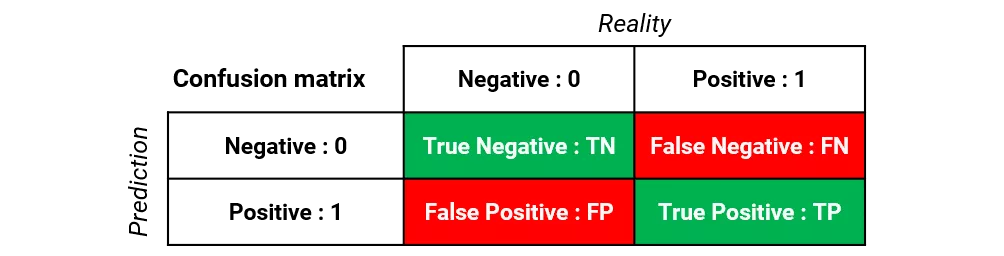

De ce fait, les prêts accordés aux individus qui ne sont finalement pas solvables sont dotés d'une pénalisation négative de -10. Ce rapport 10 est totalement arbitraire et il est tout à fait possible de changer ces valeurs à la convenance de l'optique métier.

In [ ]:
# Définition de la métrique 'banking'
def Ind_bank(y_test, y_pred, fn_value=-10, fp_value=-1, tp_value=0, tn_value=0):

    # Matrice de Confusion
    mat_conf = confusion_matrix(y_test, y_pred)

    # Nombre de True Negatifs
    tn = mat_conf[0, 0]
    # Nombre de Faux Négatifs
    fn = mat_conf[1, 0]
    # Nombre de Faux Positifs
    fp = mat_conf[0, 1]
    # Nombre de True Positifs
    tp = mat_conf[1, 1]

    # Gain normalisé entre 0 et 1
    J_normalized = fn_value*fn + fp_value*fp

    return J_normalized  # Retourne la fonction d'évaluation

# Evolution du gain en fonction du seuil de solvabilité fixé Si score < seuil : client solvable, Sinon : client non solvable
def gain_seuil(y_pred_1, y_set):

    """
    Evolution du gain en fonction du seuil de solvabilité fixé
    Si score < seuil : client solvable
    Sinon : client non solvable

    """
    cost_function = []
    threshold_x = np.linspace(0.0, 1, 1000)

    for threshold in threshold_x:


        # y_pred_1 > seuil de solvabilité : retourne 1 sinon 0
        y_pred = (y_pred_1 > threshold)

        y_pred = np.array(y_pred > 0) * 1
        # Calcul de l'indice bancaire
        cost_function.append(Ind_bank(y_set, y_pred))


    # Affichage du gain en fonction du seuil de solvabilité
    plt.figure(figsize=(8, 8))
    plt.plot(threshold_x, cost_function)
    annot_max(threshold_x,cost_function)
    plt.grid()
    plt.xlabel("Seuil de probabilité")
    plt.ylabel("Indice banquaire")
    plt.xticks(np.linspace(0.1, 1, 10))


# Fonction pour annoter le seuil de solvabilité dans le graphique
def annot_max(x,y, ax=None):
    ymax = max(y)
    xpos = np.argmax(y)
    xmax = x[xpos]

    text= "Seuil de solvabilité={:.3f}".format(xmax)
    plt.axvline(xmax, c='red', linewidth=0.9,  alpha=0.8)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(facecolor='white', fc ="0.99", edgecolor='black', boxstyle='round')
    arrowprops=dict(arrowstyle = "->",connectionstyle = "angle,angleA=90,angleB=180,rad=0",color='black')
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="right", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw)

Graphique avec le seuil métier

In [ ]:
gain_seuil(y_pred_1, y_test)

In [ ]:
# Définition d'un seuil de classification
threshold = 0.617
pred_metier = (y_pred_smote[:,1] > threshold).astype(int)

cm = confusion_matrix(y_test, pred_metier)

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

print('Classification Report')
print(classification_report(y_test, pred_metier))

Afficher les scores

In [ ]:
print('LightGBM RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, pred_metier)))
print('LightGBM RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, pred_metier)))

print('LightGBM RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, pred_metier)))
print('LightGBM RandomizedSearchCV Model ROCAUC score: {0:0.4f}'.format(roc_auc_score(y_test, pred_metier)))
print('LightGBM RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, pred_metier)))

## Méthode 2 : Oversampling

In [ ]:
print("shape target before handling",'\n',y.value_counts())

over  = RandomOverSampler(sampling_strategy=0.5)

pipe_over = Pipeline([
                ('over', over)
                ])
X_over, y_over = pipe_over.fit_resample(X_train, y_train)

print("shape target after handling",'\n',y_over.value_counts())

In [ ]:
param_distributions_over={
                            'colsample_bytree': [0.1],
                            'learning_rate': [0.09],
                            'max_depth': [5],
                            'min_child_samples': [10],
                            'min_child_weight': [5],
                            'n_estimators': [1000],
                            'num_leaves': [20],
                            'reg_alpha': [20],
                            'reg_lambda': [100],
                            'scale_pos_weight': [7]
}

Validation croisée RandomizedSearchCV :

In [ ]:
pipeline = Pipeline([
                    ('lgbm', LGBMClassifier())
                ])
params_lgbm = {'lgbm__' + key: param_distributions_over[key] for key in param_distributions_over}

random_search_over = RandomizedSearchCV(estimator=pipeline,
                           param_distributions=params_lgbm,
                           scoring='balanced_accuracy',
                           cv=kf)

random_search_over.fit(X_over, y_over)

Les meilleurs hyper paramètres utilisés

In [ ]:
best_param = random_search_over.best_params_
best_param

Meilleur score du RandomizedSearchCV

In [ ]:
random_search_over.best_score_

Enregistrer le meilleur modèle

In [ ]:
best_lgbm_over = random_search_over.best_estimator_

Sauvegarder le modèle

In [ ]:
# pk.dump(best_lgbm_over, open("Model/best_lgbm_over.pkl","wb"))

Prédire le résultat sur les données test

In [ ]:
y_pred_over=best_lgbm_over.predict_proba(X_test)

Score AUC

In [ ]:
print('LightGBM RandomizedSearchCV Model ROCAUC score: {0:0.4f}'.format(roc_auc_score(y_test, y_pred_over[:, 1])))

Afficher les scores

In [ ]:
print('LightGBM RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, np.argmax(y_pred_over,axis = 1))))
print('LightGBM RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, np.argmax(y_pred_over,axis = 1))))

print('LightGBM RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, np.argmax(y_pred_over,axis = 1))))
print('LightGBM RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, np.argmax(y_pred_over,axis = 1))))

Rapport de classification

In [ ]:
print('Classification Report')
print(classification_report(y_test, np.argmax(y_pred_over,axis = 1)))

Matrice de confusion - vérifier l'exactitude

In [ ]:
cm = confusion_matrix(y_test, np.argmax(y_pred_over,axis = 1))

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

### Seuil optimal pour la courbe ROC

Garder les probabilités que pour le résultat positif

In [ ]:
y_pred_1 = y_pred_over[:, 1]

Calculer roc_curve pour obtenir le meilleur seuil

In [ ]:
# calculer roc curves
fpr, tpr, thresholds = roc_curve(y_test, y_pred_1)
# Meilleur seuil
J = tpr - fpr
ix = argmax(J)
best_thresh = thresholds[ix]
print('Best Threshold=%f' % (best_thresh))

Graphique ROC pour le modèle avec la classification déséquilibrée avec le seuil optimal

In [ ]:
plt.figure(figsize=(7,7))

# graphique roc curve du modèle
pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.', label='ROC')
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best',s=100)
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()

plt.title('Courbe ROC')
annot_auc(fpr[ix],tpr[ix])
# Afficher le graphique
pyplot.show()

Matrice de confusion

In [ ]:
thresh_roc =proba_to_class(y_pred_1, tune_threshold(y_test, y_pred_1))

cm = confusion_matrix(y_test,thresh_roc)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

Classification Report

In [ ]:
print('Classification Report')
print(classification_report(y_test, thresh_roc))

Afficher les scores

In [ ]:
print('LightGBM RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, thresh_roc)))
print('LightGBM RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, thresh_roc)))

print('LightGBM RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, thresh_roc)))
print('LightGBM RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, thresh_roc)))

### Seuil optimal pour la courbe de rappel / précision

Définir des seuils

In [ ]:
# calculate pr-curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_1)

Evaluer chaque seuil

In [ ]:
# convert to f score
fscore = (2 * precision * recall) / (precision + recall)
# locate the index of the largest f score
ix = argmax(fscore)
print('Best Threshold=%f, F-Score=%.3f' % (thresholds[ix], fscore[ix]))

In [ ]:
# plot the roc curve for the model
plt.figure(figsize=(7,7))
no_skill = len(y_test[y_test==1]) / len(y_test)
pyplot.plot([0,1], [no_skill,no_skill], linestyle='--', label='No Skill')
pyplot.plot(recall, precision, marker='.', label='')
pyplot.scatter(recall[ix], precision[ix], marker='o', color='black', label='Best',s=100)
# axis labels
pyplot.xlabel('Recall')
pyplot.ylabel('Precision')
pyplot.legend()

plt.title('Courbe Recall/Precision')
annot_auc(recall[ix],precision[ix])
# show the plot
pyplot.show()

Fonction pour créer des labels en appliquant le seuil aux probabilités positives

In [ ]:
thresh_precision_recall =to_labels(y_pred_1, thresholds[ix])

In [ ]:
cm = confusion_matrix(y_test, thresh_precision_recall)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

Classification Report

In [ ]:
print('Classification Report')
print(classification_report(y_test, thresh_precision_recall))

Afficher les scores

In [ ]:
print('LightGBM RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, thresh_precision_recall)))
print('LightGBM RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, thresh_precision_recall)))

print('LightGBM RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, thresh_precision_recall)))
print('LightGBM RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, thresh_precision_recall)))

### Seuil métier

Graphique avec le seuil métier

In [ ]:
gain_seuil(y_pred_1, y_test)

In [ ]:
# Définition d'un seuil de classification
threshold = 0.750
pred_metier = (y_pred_over[:,1] > threshold).astype(int)

cm = confusion_matrix(y_test, pred_metier)

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

print('Classification Report')
print(classification_report(y_test, pred_metier))

Afficher les scores

In [ ]:
print('LightGBM RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, pred_metier)))
print('LightGBM RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, pred_metier)))

print('LightGBM RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, pred_metier)))
print('LightGBM RandomizedSearchCV Model ROCAUC score: {0:0.4f}'.format(roc_auc_score(y_test, pred_metier)))
print('LightGBM RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, pred_metier)))

Afficher les caractéristiques les plus importantes :

In [ ]:
import warnings
# Créer dataframe des caractéristiques les plus importantes
df_feature_importance=pd.DataFrame({'Features': df_train1.iloc[ :, 2:].columns,
              'Features_importance':best_lgbm_over['lgbm'].feature_importances_
              })

df_feature_importance_20 = df_feature_importance.sort_values(by='Features_importance', ascending=False).head(20)
# df_feature_importance.sort_values(by='Features_importance', ascending=False).head(20).to_csv('df_feature_importance.csv', index = False)

# Graphique des caractéristiques les plus importantes
fig, ax = plt.subplots()

ax = sns.barplot(x="Features_importance", y="Features", data=df_feature_importance_20, palette="husl")

# Ajouter les annotations sur les barres
for p in ax.patches:
    ax.annotate("%.0f" % p.get_width(), xy=(p.get_width(), p.get_y()+p.get_height()/2),
                xytext=(5, 0), textcoords='offset points', ha="left", va="center")

# Ajouter des textes aux labels, titre etc.
fig.set_size_inches(7, 8)
ax.set_title("Les 20 caractéristiques les plus importantes\n", fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=12)
plt.show()

## Méthode 3 : Undersampling

In [ ]:
print("shape target before handling",'\n',y.value_counts())

under = RandomUnderSampler(sampling_strategy=0.5)

pipe_under = Pipeline([
                ('under', under)
                ])
X_under, y_under = pipe_under.fit_resample(X_train, y_train)

print("shape target after handling",'\n',y_under.value_counts())

Validation croisée RandomizedSearchCV :

In [ ]:
pipeline = Pipeline([
                    ('lgbm', LGBMClassifier())
                ])
params_lgbm = {'lgbm__' + key: param_distributions[key] for key in param_distributions}

random_search_under = RandomizedSearchCV(estimator=pipeline,
                                         param_distributions=params_lgbm,
                                         scoring='balanced_accuracy',
                                         cv=kf)

random_search_under.fit(X_under, y_under)

In [ ]:
# Number of classes in training Data
y_under.value_counts()

Les meilleurs hyper paramètres utilisés

In [ ]:
best_param = random_search_under.best_params_
best_param

Meilleur score du RandomizedSearchCV

In [ ]:
random_search_under.best_score_

Enregistrer le meilleur modèle

In [ ]:
best_lgbm_under = random_search_under.best_estimator_

Prédire le résultat sur les données test

In [ ]:
y_pred_under=best_lgbm_under.predict_proba(X_test)

Score AUC

In [ ]:
print('LightGBM RandomizedSearchCV Model ROCAUC score: {0:0.4f}'.format(roc_auc_score(y_test, y_pred_under[:, 1])))

Afficher les scores

In [ ]:
print('LightGBM RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, np.argmax(y_pred_under,axis = 1))))
print('LightGBM RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, np.argmax(y_pred_under,axis = 1))))

print('LightGBM RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, np.argmax(y_pred_under,axis = 1))))
print('LightGBM RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, np.argmax(y_pred_under,axis = 1))))

Rapport de classification

In [ ]:
print('Classification Report')
print(classification_report(y_test, np.argmax(y_pred_under,axis = 1)))

Matrice de confusion - vérifier l'exactitude

In [ ]:
cm = confusion_matrix(y_test, np.argmax(y_pred_under,axis = 1))

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

### Seuil optimal pour la courbe ROC

Garder les probabilités que pour le résultat positif

In [ ]:
y_pred_1 = y_pred_under[:, 1]

Calculer roc_curve pour obtenir le meilleur seuil

In [ ]:
# calculer roc curves
fpr, tpr, thresholds = roc_curve(y_test, y_pred_1)
# Meilleur seuil
J = tpr - fpr
ix = argmax(J)
best_thresh = thresholds[ix]
print('Best Threshold=%f' % (best_thresh))

Graphique ROC pour le modèle avec la classification déséquilibrée avec le seuil optimal

In [ ]:
plt.figure(figsize=(7,7))

# graphique roc curve du modèle
pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.', label='')
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best',s=100)
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()

plt.title('Courbe ROC')
annot_auc(fpr[ix],tpr[ix])
# Afficher le graphique
pyplot.show()

Matrice de confusion

In [ ]:
thresh_roc =proba_to_class(y_pred_1, tune_threshold(y_test, y_pred_1))

cm = confusion_matrix(y_test,thresh_roc)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

Classification Report

In [ ]:
print('Classification Report')
print(classification_report(y_test, thresh_roc))

Afficher les scores

In [ ]:
print('LightGBM RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, thresh_roc)))
print('LightGBM RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, thresh_roc)))

print('LightGBM RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, thresh_roc)))
print('LightGBM RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, thresh_roc)))

### Seuil optimal pour la courbe de rappel / précision

Définir des seuils

In [ ]:
# calculate pr-curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_1)

Evaluer chaque seuil

In [ ]:
# convert to f score
fscore = (2 * precision * recall) / (precision + recall)
# locate the index of the largest f score
ix = argmax(fscore)
print('Best Threshold=%f, F-Score=%.3f' % (thresholds[ix], fscore[ix]))

In [ ]:
# plot the roc curve for the model
plt.figure(figsize=(7,7))
no_skill = len(y_test[y_test==1]) / len(y_test)
pyplot.plot([0,1], [no_skill,no_skill], linestyle='--', label='No Skill')
pyplot.plot(recall, precision, marker='.', label='')
pyplot.scatter(recall[ix], precision[ix], marker='o', color='black', label='Best',s=100)
# axis labels
pyplot.xlabel('Recall')
pyplot.ylabel('Precision')
pyplot.legend()

plt.title('Courbe Précision/Rappel')
annot_auc(recall[ix],precision[ix])
# show the plot
pyplot.show()

Fonction pour créer des labels en appliquant le seuil aux probabilités positives

In [ ]:
def to_labels(pos_probs, threshold):
	return (pos_probs >= threshold).astype('int')
thresh_precision_recall =to_labels(y_pred_1, thresholds[ix])

In [ ]:
cm = confusion_matrix(y_test, thresh_precision_recall)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

Classification Report

In [ ]:
print('Classification Report')
print(classification_report(y_test, thresh_precision_recall))

Afficher les scores

In [ ]:
print('LightGBM RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, thresh_precision_recall)))
print('LightGBM RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, thresh_precision_recall)))

print('LightGBM RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, thresh_precision_recall)))
print('LightGBM RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, thresh_precision_recall)))

In [ ]:
# lgbm.plot_importance(best_lgbm_under['lgbm'] ,max_num_features=20, figsize=(12,12))
# plt.show()

### Seuil métier

Graphique avec le seuil métier

In [ ]:
gain_seuil(y_pred_1, y_test)

In [ ]:
# Définition d'un seuil de classification
threshold = 0.702
pred_metier = (y_pred_under[:,1] > threshold).astype(int)

cm = confusion_matrix(y_test, pred_metier)

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

print('Classification Report')
print(classification_report(y_test, pred_metier))

Afficher les scores

In [ ]:
print('LightGBM RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, pred_metier)))
print('LightGBM RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, pred_metier)))

print('LightGBM RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, pred_metier)))
print('LightGBM RandomizedSearchCV Model ROCAUC score: {0:0.4f}'.format(roc_auc_score(y_test, pred_metier)))
print('LightGBM RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, pred_metier)))

Afficher les caractéristiques les plus importantes :

In [ ]:
import warnings
# Créer dataframe des caractéristiques les plus importantes
df_feature_importance=pd.DataFrame({'Features': df_train1.iloc[ :, 2:].columns,
              'Features_importance':best_lgbm_under['lgbm'].feature_importances_
              })

df_feature_importance_20 = df_feature_importance.sort_values(by='Features_importance', ascending=False).head(20)
# df_feature_importance.sort_values(by='Features_importance', ascending=False).head(20).to_csv('df_feature_importance.csv', index = False)

# Graphique des caractéristiques les plus importantes
fig, ax = plt.subplots()

ax = sns.barplot(x="Features_importance", y="Features", data=df_feature_importance_20, palette="husl")

# Ajouter les annotations sur les barres
for p in ax.patches:
    ax.annotate("%.0f" % p.get_width(), xy=(p.get_width(), p.get_y()+p.get_height()/2),
                xytext=(5, 0), textcoords='offset points', ha="left", va="center")

# Ajouter des textes aux labels, titre etc.
fig.set_size_inches(7, 8)
ax.set_title("Les 20 caractéristiques les plus importantes\n", fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=12)
plt.show()

# <font color='blue'/>**Random Forest**

---

## Méthode 1 : SMOTE

In [ ]:
X = df_train1.iloc[ :, 2:]
y = df_train1.iloc[ :,1]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=120,stratify=y)

Nous allons nous assurer que nous avons les mêmes fractionnements de données à chaque fois. Nous pouvons nous en assurer en créant un KFold objet kf, et en passant cv=kf à la place du plus commun cv=5

In [ ]:
kf = KFold(n_splits=5,shuffle=False)

Déclaration des paramètres pour RandomizedSearchCV

In [ ]:
param_distributions = {

                        'n_estimators': [400],
                        'max_depth': [20],
                        #'criterion':['gini'],
                        'max_features':['auto'],
                        # 'min_impurity_decrease':[0.0],
                        'min_samples_leaf':[5],
                        'min_samples_split':[2],
                        # 'min_weight_fraction_leaf':[0.0],
                        'n_jobs':[-1],
                        # 'random_state':[50],
                        #'verbose':[1],

                        #'colsample_bytree': np.linspace(0.01, 0.5, 40),
                        #'min_child_samples': [10,20,50],
                    }

Validation croisée RandomizedSearchCV :

Nous allons utiliser SMOTE dans le cadre d'un pipeline. Ce pipeline n'est pas un pipeline "Scikit-Learn", mais un pipeline "imblearn".

Étant donné que SMOTE n'a pas de méthode 'fit_transform', nous ne pouvons pas l'utiliser avec le pipeline 'Scikit-Learn'.

In [ ]:
pipeline = Pipeline([
        ('smote', SMOTE()),
        ('rfc', RandomForestClassifier())
    ])

params_rfc = {'rfc__' + key: param_distributions[key] for key in param_distributions}

random_search_smote = RandomizedSearchCV(estimator=pipeline,
                           param_distributions=params_rfc,
                           scoring='roc_auc',
                           n_iter=5,
                           cv=kf)

random_search_smote.fit(X_train, y_train)

In [ ]:
y_train.value_counts()

Les meilleurs hyper paramètres utilisés

In [ ]:
best_param = random_search_smote.best_params_
best_param

Meilleur score du RandomizedSearchCV

In [ ]:
random_search_smote.best_score_

Enregistrer le meilleur modèle

In [ ]:
best_rfc_smote = random_search_smote.best_estimator_

Prédire le résultat sur les données test

In [ ]:
y_pred_smote=best_rfc_smote.predict_proba(X_test)

Score AUC

In [ ]:
print('RForest RandomizedSearchCV Model ROCAUC score: {0:0.4f}'.format(roc_auc_score(y_test, y_pred_smote[:, 1])))

Afficher les scores

In [ ]:
print('RForest RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, np.argmax(y_pred_smote,axis = 1))))
print('RForest RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, np.argmax(y_pred_smote,axis = 1))))

print('RForest RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, np.argmax(y_pred_smote,axis = 1))))
print('RForest RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, np.argmax(y_pred_smote,axis = 1))))

In [ ]:
print('Score test   : ', best_rfc_smote.score(X_test,y_test))
print('Score train  : ', best_rfc_smote.score(X_train,y_train))

Rapport de classification

In [ ]:
print('Classification Report')
print(classification_report(y_test, np.argmax(y_pred_smote,axis = 1)))

Matrice de confusion - vérifier l'exactitude

In [ ]:
cm = confusion_matrix(y_test, np.argmax(y_pred_smote,axis = 1))

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

### Seuil optimal pour la courbe ROC

Garder les probabilités que pour le résultat positif

In [ ]:
y_pred_1 = y_pred_smote[:, 1]

Calculer roc_curve pour obtenir le meilleur seuil

In [ ]:
# calculer roc curves
fpr, tpr, thresholds = roc_curve(y_test, y_pred_1)
# Meilleur seuil
J = tpr - fpr
ix = argmax(J)
best_thresh = thresholds[ix]
print('Best Threshold=%f' % (best_thresh))

Graphique ROC pour le modèle avec la classification déséquilibrée avec le seuil optimal

In [ ]:
plt.figure(figsize=(7,7))

# graphique roc curve du modèle
pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.', label='ROC')
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best',s=100)
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()

plt.title('Courbe ROC')

annot_auc(fpr[ix],tpr[ix])

# Afficher le graphique
pyplot.show()

Matrice de confusion

In [ ]:
thresh_roc =proba_to_class(y_pred_1, tune_threshold(y_test, y_pred_1))

cm = confusion_matrix(y_test,thresh_roc)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

Classification Report

In [ ]:
print('Classification Report')
print(classification_report(y_test, thresh_roc))

Afficher les scores

In [ ]:
print('RForest RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, thresh_roc)))
print('RForest RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, thresh_roc)))

print('RForest RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, thresh_roc)))
print('RForest RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, thresh_roc)))

### Seuil optimal pour la courbe de rappel / précision

Définir des seuils

In [ ]:
# calculate pr-curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_1)

Evaluer chaque seuil

In [ ]:
# convert to f score
fscore = (2 * precision * recall) / (precision + recall)
# locate the index of the largest f score
ix = argmax(fscore)
print('Best Threshold=%f, F-Score=%.3f' % (thresholds[ix], fscore[ix]))

In [ ]:
# plot the roc curve for the model
plt.figure(figsize=(7,7))
no_skill = len(y_test[y_test==1]) / len(y_test)
pyplot.plot([0,1], [no_skill,no_skill], linestyle='--', label='No Skill')
pyplot.plot(recall, precision, marker='.', label='')
pyplot.scatter(recall[ix], precision[ix], marker='o', color='black', label='Best',s=100)
# axis labels
pyplot.xlabel('Recall')
pyplot.ylabel('Precision')
pyplot.legend()

plt.title('Courbe Précision/Rappel')
annot_auc(recall[ix],precision[ix])

# show the plot
pyplot.show()

Fonction pour créer des labels en appliquant le seuil aux probabilités positives

In [ ]:
def to_labels(pos_probs, threshold):
	return (pos_probs >= threshold).astype('int')
thresh_precision_recall =to_labels(y_pred_1, thresholds[ix])

In [ ]:
cm = confusion_matrix(y_test, thresh_precision_recall)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

Classification Report

In [ ]:
print('Classification Report')
print(classification_report(y_test, thresh_precision_recall))

Afficher les scores

In [ ]:
print('RForest RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, thresh_precision_recall)))
print('RForest RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, thresh_precision_recall)))

print('RForest RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, thresh_precision_recall)))
print('RForest RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, thresh_precision_recall)))

## Méthode 2 : Oversampling

In [ ]:
print("shape target before handling",'\n',y.value_counts())

over  = RandomOverSampler(sampling_strategy='minority')

pipe_over = Pipeline([
                ('over', over)
                ])
X_over, y_over = pipe_over.fit_resample(X_train, y_train)

print("shape target after handling",'\n',y_over.value_counts())

Validation croisée RandomizedSearchCV :

In [ ]:
pipeline = Pipeline([
                    ('rfc', RandomForestClassifier())
                ])
params_rfc = {'rfc__' + key: param_distributions[key] for key in param_distributions}

random_search_over = RandomizedSearchCV(estimator=pipeline,
                           param_distributions=params_rfc,
                           scoring='balanced_accuracy',
                           cv=kf)

random_search_over.fit(X_over, y_over)

In [ ]:
pipeline = Pipeline([
                    ('rfc', RandomForestClassifier())
                ])
pipeline.steps[0][1]

Les meilleurs hyper paramètres utilisés

In [ ]:
best_param = random_search_over.best_params_
best_param

Meilleur score du RandomizedSearchCV

In [ ]:
random_search_over.best_score_

Enregistrer le meilleur modèle

In [ ]:
best_rfc_over = random_search_over.best_estimator_
# pk.dump(best_rfc_over, open("best_rfc_over.pkl","wb"))

In [ ]:
best_rfc_over.steps[0][1]

Prédire le résultat sur les données test

In [ ]:
y_pred_over=best_rfc_over.predict_proba(X_test)

Score AUC

In [ ]:
print('RForest RandomizedSearchCV Model ROCAUC score: {0:0.4f}'.format(roc_auc_score(y_test, y_pred_over[:, 1])))

Afficher les scores

In [ ]:
print('RForest RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, np.argmax(y_pred_over,axis = 1))))
print('RForest RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, np.argmax(y_pred_over,axis = 1))))

print('RForest RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, np.argmax(y_pred_over,axis = 1))))
print('RForest RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, np.argmax(y_pred_over,axis = 1))))

Rapport de classification

In [ ]:
print('Classification Report')
print(classification_report(y_test, np.argmax(y_pred_over,axis = 1)))

Matrice de confusion - vérifier l'exactitude

In [ ]:
cm = confusion_matrix(y_test, np.argmax(y_pred_over,axis = 1))

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

### Seuil optimal pour la courbe ROC

Garder les probabilités que pour le résultat positif

In [ ]:
y_pred_1 = y_pred_over[:, 1]

Calculer roc_curve pour obtenir le meilleur seuil

In [ ]:
# calculer roc curves
fpr, tpr, thresholds = roc_curve(y_test, y_pred_1)
# Meilleur seuil
J = tpr - fpr
ix = argmax(J)
best_thresh = thresholds[ix]
print('Best Threshold=%f' % (best_thresh))

Graphique ROC pour le modèle avec la classification déséquilibrée avec le seuil optimal

In [ ]:
plt.figure(figsize=(7,7))

# graphique roc curve du modèle
pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.', label='ROC')
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best',s=100)
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()

plt.title('Courbe ROC')
annot_auc(fpr[ix],tpr[ix])
# Afficher le graphique
pyplot.show()

Matrice de confusion

In [ ]:
thresh_roc =proba_to_class(y_pred_1, tune_threshold(y_test, y_pred_1))

cm = confusion_matrix(y_test,thresh_roc)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

Classification Report

In [ ]:
print('Classification Report')
print(classification_report(y_test, thresh_roc))

Afficher les scores

In [ ]:
print('RForest RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, thresh_roc)))
print('RForest RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, thresh_roc)))

print('RForest RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, thresh_roc)))
print('RForest RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, thresh_roc)))

### Seuil optimal pour la courbe de rappel / précision

Définir des seuils

In [ ]:
# calculate pr-curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_1)

Evaluer chaque seuil

In [ ]:
# convert to f score
fscore = (2 * precision * recall) / (precision + recall)
# locate the index of the largest f score
ix = argmax(fscore)
print('Best Threshold=%f, F-Score=%.3f' % (thresholds[ix], fscore[ix]))

In [ ]:
# plot the roc curve for the model
plt.figure(figsize=(7,7))
no_skill = len(y_test[y_test==1]) / len(y_test)
pyplot.plot([0,1], [no_skill,no_skill], linestyle='--', label='No Skill')
pyplot.plot(recall, precision, marker='.', label='')
pyplot.scatter(recall[ix], precision[ix], marker='o', color='black', label='Best',s=100)
# axis labels
pyplot.xlabel('Recall')
pyplot.ylabel('Precision')
pyplot.legend()

plt.title('Courbe Recall/Precision')
annot_auc(recall[ix],precision[ix])
# show the plot
pyplot.show()

Fonction pour créer des labels en appliquant le seuil aux probabilités positives

In [ ]:
thresh_precision_recall =to_labels(y_pred_1, thresholds[ix])

In [ ]:
cm = confusion_matrix(y_test, thresh_precision_recall)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

Classification Report

In [ ]:
print('Classification Report')
print(classification_report(y_test, thresh_precision_recall))

Afficher les scores

In [ ]:
print('RForest RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, thresh_precision_recall)))
print('RForest RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, thresh_precision_recall)))

print('RForest RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, thresh_precision_recall)))
print('RForest RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, thresh_precision_recall)))

## Méthode 3 : Undersampling

In [ ]:
print("shape target before handling",'\n',y.value_counts())

under = RandomUnderSampler(sampling_strategy=0.5)

pipe_under = Pipeline([
                ('under', under)
                ])
X_under, y_under = pipe_under.fit_resample(X_train, y_train)

print("shape target after handling",'\n',y_under.value_counts())

Validation croisée RandomizedSearchCV :

In [ ]:
pipeline = Pipeline([
                    ('rfc', RandomForestClassifier())
                ])
params_rfc = {'rfc__' + key: param_distributions[key] for key in param_distributions}

random_search_under = RandomizedSearchCV(estimator=pipeline,
                                         param_distributions=params_rfc,
                                         scoring='balanced_accuracy',
                                         cv=kf)

random_search_under.fit(X_under, y_under)

In [ ]:
# Number of classes in training Data
y_under.value_counts()

Les meilleurs hyper paramètres utilisés

In [ ]:
best_param = random_search_under.best_params_
best_param

Meilleur score du RandomizedSearchCV

In [ ]:
random_search_under.best_score_

Enregistrer le meilleur modèle

In [ ]:
best_rfc_under = random_search_under.best_estimator_

Prédire le résultat sur les données test

In [ ]:
y_pred_under=best_rfc_under.predict_proba(X_test)

Score AUC

In [ ]:
print('RForest RandomizedSearchCV Model ROCAUC score: {0:0.4f}'.format(roc_auc_score(y_test, y_pred_under[:, 1])))

Afficher les scores

In [ ]:
print('RForest RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, np.argmax(y_pred_under,axis = 1))))
print('RForest RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, np.argmax(y_pred_under,axis = 1))))

print('RForest RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, np.argmax(y_pred_under,axis = 1))))
print('RForest RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, np.argmax(y_pred_under,axis = 1))))

Rapport de classification

In [ ]:
print('Classification Report')
print(classification_report(y_test, np.argmax(y_pred_under,axis = 1)))

Matrice de confusion - vérifier l'exactitude

In [ ]:
cm = confusion_matrix(y_test, np.argmax(y_pred_under,axis = 1))

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

### Seuil optimal pour la courbe ROC

Garder les probabilités que pour le résultat positif

In [ ]:
y_pred_1 = y_pred_under[:, 1]

Calculer roc_curve pour obtenir le meilleur seuil

In [ ]:
# calculer roc curves
fpr, tpr, thresholds = roc_curve(y_test, y_pred_1)
# Meilleur seuil
J = tpr - fpr
ix = argmax(J)
best_thresh = thresholds[ix]
print('Best Threshold=%f' % (best_thresh))

Graphique ROC pour le modèle avec la classification déséquilibrée avec le seuil optimal

In [ ]:
plt.figure(figsize=(7,7))

# graphique roc curve du modèle
pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.', label='')
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best',s=100)
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()

plt.title('Courbe ROC')
annot_auc(fpr[ix],tpr[ix])
# Afficher le graphique
pyplot.show()

Matrice de confusion

In [ ]:
thresh_roc =proba_to_class(y_pred_1, tune_threshold(y_test, y_pred_1))

cm = confusion_matrix(y_test,thresh_roc)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

Classification Report

In [ ]:
print('Classification Report')
print(classification_report(y_test, thresh_roc))

Afficher les scores

In [ ]:
print('RForest RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, thresh_roc)))
print('RForest RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, thresh_roc)))

print('RForest RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, thresh_roc)))
print('RForest RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, thresh_roc)))

### Seuil optimal pour la courbe de rappel / précision

Définir des seuils

In [ ]:
# calculate pr-curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_1)

Evaluer chaque seuil

In [ ]:
# convert to f score
fscore = (2 * precision * recall) / (precision + recall)
# locate the index of the largest f score
ix = argmax(fscore)
print('Best Threshold=%f, F-Score=%.3f' % (thresholds[ix], fscore[ix]))

In [ ]:
# plot the roc curve for the model
plt.figure(figsize=(7,7))
no_skill = len(y_test[y_test==1]) / len(y_test)
pyplot.plot([0,1], [no_skill,no_skill], linestyle='--', label='No Skill')
pyplot.plot(recall, precision, marker='.', label='')
pyplot.scatter(recall[ix], precision[ix], marker='o', color='black', label='Best',s=100)
# axis labels
pyplot.xlabel('Recall')
pyplot.ylabel('Precision')
pyplot.legend()

plt.title('Courbe Précision/Rappel')
annot_auc(recall[ix],precision[ix])
# show the plot
pyplot.show()

Fonction pour créer des labels en appliquant le seuil aux probabilités positives

In [ ]:
thresh_precision_recall =to_labels(y_pred_1, thresholds[ix])

In [ ]:
cm = confusion_matrix(y_test, thresh_precision_recall)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8,6))
ax= plt.subplot()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No Default', 'In Default'])
ax.yaxis.set_ticklabels(['No Default', 'In Default'])

Classification Report

In [ ]:
print('Classification Report')
print(classification_report(y_test, thresh_precision_recall))

Afficher les scores

In [ ]:
print('RForest RandomizedSearchCV Model precision score: {0:0.4f}'.format(precision_score(y_test, thresh_precision_recall)))
print('RForest RandomizedSearchCV Model recall score: {0:0.4f}'.format(recall_score(y_test, thresh_precision_recall)))

print('RForest RandomizedSearchCV Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, thresh_precision_recall)))
print('RForest RandomizedSearchCV Model F1 score: {0:0.4f}'.format(f1_score(y_test, thresh_precision_recall)))

# <font color='blue'/>**Analyse Shapley**

---

L'interprétation du modèle avec SHAP

In [ ]:
# Initialiser SHAP Tree explainer
explainer = shap.TreeExplainer(best_lgbm_over['lgbm'])
shap_values = explainer.shap_values(X_test)

# Baseline value
expected_value = explainer.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[1]
print(f"Explainer expected value: {expected_value}")

Résumez le poids de toutes les features

In [ ]:
shap.summary_plot(shap_values, X_test)

Extraire les 20 features les plus importantes avec Shapley

In [ ]:
vals= np.abs(shap_values[1]).mean(0)
df_feature_importance = pd.DataFrame(list(zip(X_train.columns,vals)),columns=['Features','Features_importance_shapley'])
df_feature_importance.sort_values(by=['Features_importance_shapley'],ascending=False,inplace=True)

df_feature_importance_20 = df_feature_importance.head(20)
# Graphique des caractéristiques les plus importantes
fig, ax = plt.subplots()

ax = sns.barplot(x="Features_importance_shapley", y="Features", data=df_feature_importance_20, palette="husl")

# Ajouter les annotations sur les barres
for p in ax.patches:
    ax.annotate("%.2f" % p.get_width(), xy=(p.get_width(), p.get_y()+p.get_height()/2),
                xytext=(5, 0), textcoords='offset points', ha="left", va="center")

# Ajouter des textes aux labels, titre etc.
fig.set_size_inches(7, 8)
ax.set_title("Les 20 caractéristiques Shapley les plus importantes\n", fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
shap.initjs()
# def plot_explainer_client(j):
#     return shap.force_plot(expected_value, shap_values[0][j], X_test.iloc[j],
#                            matplotlib = True, show = True, text_rotation=45,link='identity')

# plot_explainer_client(262)
index_client = 25
shap.force_plot(expected_value, shap_values[1][index_client],X_test.iloc[index_client],link='identity')

Graphique cleint Waterfall

In [ ]:
index_client = 30
shap.plots._waterfall.waterfall_legacy(expected_value,
                                        shap_values[1][index_client],
                                        feature_names = X_test.columns,
                                        max_display = 20)

Graphique cleint Decision plot

In [ ]:
shap.decision_plot(base_value=explainer.expected_value[1],
                                          shap_values=shap_values[1][index_client],
                                          features=df_train1.iloc[index_client:, 2:-2],
                                          feature_names=df_train1.iloc[:, 2:].columns.tolist())